# Técnicas de Transformación de Datos
## Guía teórico-práctica con ejemplos simples

> Cada sección incluye la **teoría** de la técnica y un **ejemplo mínimo**  
> con un DataFrame para que el concepto quede claro antes de aplicarlo a datos reales.

---

### Las 5 grandes categorías de transformación

En lugar de memorizar una lista de técnicas sueltas, agrupamos todo en **5 categorías conceptuales**.  
Cada técnica dentro de una categoría resuelve el **mismo tipo de problema**, solo que con distintos supuestos o distinta robustez.

| # | Categoría | Pregunta que responde | Técnicas incluidas |
|---|---|---|---|
| **1** | **Escalado de variables numéricas** | ¿Cómo pongo las variables en la misma escala? | Normalización (MinMax, MaxAbs) · Estandarización (Standard, Robust) |
| **2** | **Transformación de la forma de la distribución** | ¿Cómo corrijo la asimetría o los outliers? | log, sqrt, Box-Cox, Yeo-Johnson · Winsorizing · Quantile Transform |
| **3** | **Creación y discretización de variables** | ¿Cómo genero variables nuevas más útiles? | Discretización · Binarización · Polynomial Features · Feature Engineering · Fecha/Hora |
| **4** | **Codificación de variables categóricas** | ¿Cómo convierto texto en números? | Label · One-Hot · Ordinal · Target · Frequency · Binary |
| **5** | **Selección y reducción de dimensionalidad** | ¿Cuáles variables conservo o comprimo? | Variance Threshold · Correlación · SelectKBest · PCA · t-SNE |

> **Tip de estudio:** antes de mirar el código de una técnica, pregúntate primero *a cuál de las 5 categorías pertenece* y *qué problema general resuelve esa categoría*. El código es solo el "cómo"; la categoría es el "por qué".


---
## 0. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import (
    MinMaxScaler, MaxAbsScaler, StandardScaler, RobustScaler,
    PowerTransformer, QuantileTransformer, PolynomialFeatures,
    LabelEncoder, OrdinalEncoder, OneHotEncoder
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression

try:
    import category_encoders as ce
    CE_OK = True
except ImportError:
    CE_OK = False
    print('Tip: pip install category-encoders  (necesario para Binary Encoding)')

plt.rcParams['figure.figsize'] = (10, 4)
sns.set_style('whitegrid')
print('✓ Listo.')

✓ Listo.


---
# CATEGORÍA 1 · Escalado de Variables Numéricas

## El problema que resuelve esta categoría

Cuando dos variables tienen escalas muy distintas (ej: edad en 20-60 y salario en 1,000-100,000),  
los algoritmos basados en distancia (KNN, K-Means, SVM) tratan el salario como **miles de veces más importante**  
que la edad, simplemente por su magnitud numérica — no porque realmente lo sea.

El **escalado** pone todas las variables numéricas en un terreno común. Existen **dos enfoques distintos**  
para lograrlo, y es fundamental no confundirlos:


## Normalización vs. Estandarización — la diferencia conceptual

Ambas técnicas reescalan una variable, pero **con un objetivo distinto**:

| Aspecto | **Normalización** | **Estandarización** |
|---|---|---|
| **Objetivo** | Llevar los valores a un **rango fijo** (ej. [0,1]) | Centrar los valores en **media 0** con **dispersión 1** |
| **Fórmula** | `(x - min) / (max - min)` | `(x - media) / desviación_estándar` |
| **Rango resultante** | Fijo y acotado (ej. [0,1] o [-1,1]) | **Sin límite fijo** — depende de cuán lejos esté un valor de la media |
| **Usa como referencia** | El mínimo y el máximo | La media y la desviación estándar (o mediana e IQR) |
| **Sensibilidad a outliers** | Muy alta (el outlier define el 0 o el 1) | Alta con Standard / Baja con Robust |
| **Preserva la forma de la distribución** | Sí, solo cambia la escala | Sí, solo cambia la escala |
| **Técnicas típicas** | MinMaxScaler, MaxAbsScaler | StandardScaler, RobustScaler |
| **Se usa más con** | KNN, K-Means, redes neuronales | Regresión lineal/logística, SVM, PCA |

### La idea clave en una frase

> **Normalizar** es "encoger o estirar" los datos para que **quepan en una caja de tamaño fijo**.  
> **Estandarizar** es "recentrar" los datos alrededor de su propia media, midiendo distancias en unidades de desviación estándar — **sin caja fija**.


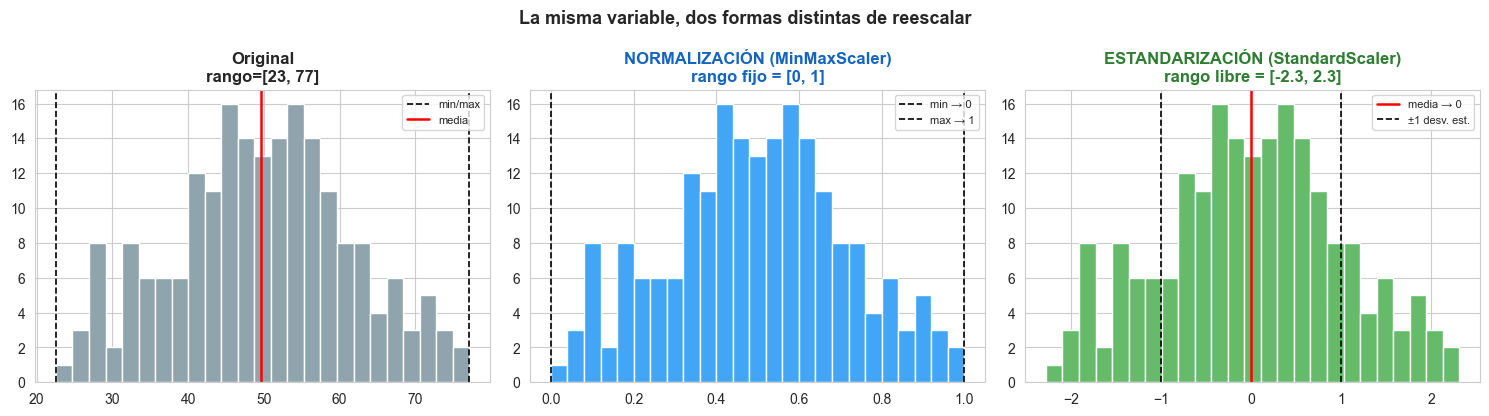

Observa: la FORMA del histograma es idéntica en los tres casos.
Solo cambia la escala del eje X — eso es lo único que hace un escalador.


In [2]:
# ── Figura conceptual: la MISMA variable, escalada de las dos formas ──
np.random.seed(7)
datos_originales = np.random.normal(loc=50, scale=12, size=200)

datos_norm = MinMaxScaler().fit_transform(datos_originales.reshape(-1,1)).flatten()
datos_std  = StandardScaler().fit_transform(datos_originales.reshape(-1,1)).flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].hist(datos_originales, bins=25, color='#90A4AE', edgecolor='white')
axes[0].axvline(datos_originales.min(), color='black', linestyle='--', linewidth=1.2, label='min/max')
axes[0].axvline(datos_originales.max(), color='black', linestyle='--', linewidth=1.2)
axes[0].axvline(datos_originales.mean(), color='red', linewidth=1.8, label='media')
axes[0].set_title(f'Original\nrango=[{datos_originales.min():.0f}, {datos_originales.max():.0f}]', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].hist(datos_norm, bins=25, color='#42A5F5', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, label='min → 0')
axes[1].axvline(1, color='black', linestyle='--', linewidth=1.2, label='max → 1')
axes[1].set_title('NORMALIZACIÓN (MinMaxScaler)\nrango fijo = [0, 1]', fontweight='bold', color='#1565C0')
axes[1].legend(fontsize=8)

axes[2].hist(datos_std, bins=25, color='#66BB6A', edgecolor='white')
axes[2].axvline(0, color='red', linewidth=1.8, label='media → 0')
axes[2].axvline(-1, color='black', linestyle='--', linewidth=1.2, label='±1 desv. est.')
axes[2].axvline(1, color='black', linestyle='--', linewidth=1.2)
axes[2].set_title(f'ESTANDARIZACIÓN (StandardScaler)\nrango libre = [{datos_std.min():.1f}, {datos_std.max():.1f}]', fontweight='bold', color='#2E7D32')
axes[2].legend(fontsize=8)

plt.suptitle('La misma variable, dos formas distintas de reescalar', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observa: la FORMA del histograma es idéntica en los tres casos.')
print('Solo cambia la escala del eje X — eso es lo único que hace un escalador.')

---
## Normalización

**Definición:** Reescalar los valores de una variable numérica a un **rango fijo**,  
sin cambiar la forma de la distribución ni las relaciones relativas entre los datos.


### MinMaxScaler

**Fórmula:** `x' = (x - min) / (max - min)` → resultado en **[0, 1]**

- El valor mínimo de la columna se convierte en **0**
- El valor máximo de la columna se convierte en **1**
- Los demás valores quedan proporcionalmente entre 0 y 1

**Cuándo usar:**
- Algoritmos sensibles a la escala: KNN, K-Means, Redes Neuronales
- Cuando se conoce el rango de los datos de antemano

**Cuándo NO usar:**
- Si hay **outliers**: el outlier se convierte en 1.0 y comprime todos los demás
- Árboles de decisión y Random Forest (no lo necesitan)


In [3]:
# Datos de ejemplo: 5 empleados con variables en escalas muy distintas
# Edad: rango 20-45  |  Salario: rango 1500-8000
# Sin escalar, Salario domina artificialmente cualquier cálculo de distancia
df = pd.DataFrame({
    'Empleado': ['Ana', 'Luis', 'María', 'Carlos', 'Pedro'],
    'Edad':    [20, 35, 28, 45, 32],
    'Salario': [1500, 4500, 2200, 8000, 3100]
})

print('ANTES de normalizar:')
print(df)

# Aplicar MinMaxScaler solo a columnas numéricas
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[['Edad', 'Salario']] = scaler.fit_transform(df[['Edad', 'Salario']])

print('\nDESPUÉS de MinMaxScaler:')
print(df_scaled.round(3))

print('\nInterpretación:')
print(f'  Ana (20 años):    edad original 20 → escalada 0.000  (es la más joven = mínimo)')
print(f'  Carlos (45 años): edad original 45 → escalada 1.000  (es el mayor = máximo)')
print(f'  María (28 años):  edad original 28 → escalada {(28-20)/(45-20):.3f}  ((28-20)/(45-20))')

ANTES de normalizar:
  Empleado  Edad  Salario
0      Ana    20     1500
1     Luis    35     4500
2    María    28     2200
3   Carlos    45     8000
4    Pedro    32     3100

DESPUÉS de MinMaxScaler:
  Empleado  Edad  Salario
0      Ana  0.00    0.000
1     Luis  0.60    0.462
2    María  0.32    0.108
3   Carlos  1.00    1.000
4    Pedro  0.48    0.246

Interpretación:
  Ana (20 años):    edad original 20 → escalada 0.000  (es la más joven = mínimo)
  Carlos (45 años): edad original 45 → escalada 1.000  (es el mayor = máximo)
  María (28 años):  edad original 28 → escalada 0.320  ((28-20)/(45-20))


### MaxAbsScaler

**Fórmula:** `x' = x / max(|x|)` → resultado en **[-1, 1]**

- Divide cada valor entre el **máximo valor absoluto** de la columna
- Si todos los valores son positivos, el resultado está en [0, 1]
- No centra los datos (no resta la media)

**Cuándo usar:**
- Datos **dispersos (sparse)** donde no se quiere destruir la dispersidad
- Cuando los datos pueden ser negativos
- Recomendado con `scipy.sparse` matrices

**Diferencia con MinMax:** no usa el mínimo, solo el máximo absoluto.


In [4]:
# Datos con valores negativos (temperatura media mensual en diferentes ciudades)
# Moscú tiene el valor absoluto más extremo: -45°C en invierno
df_temp = pd.DataFrame({
    'Ciudad':       ['Oslo', 'Cairo', 'Bogotá', 'Moscú', 'Buenos Aires'],
    'Temperatura':  [-15,    38,      18,       -45,     25]
})

print('ANTES:')
print(df_temp)

scaler_maxabs = MaxAbsScaler()
df_temp_scaled = df_temp.copy()
df_temp_scaled[['Temperatura']] = scaler_maxabs.fit_transform(df_temp[['Temperatura']])

print('\nDESPUÉS de MaxAbsScaler:')
print(df_temp_scaled.round(3))

max_abs = df_temp['Temperatura'].abs().max()
print(f'\nValor absoluto máximo: |{-45}| = {max_abs} (Moscú: -45°C)')
print(f'Todos los valores se dividen entre {max_abs}:')
for _, row in df_temp.iterrows():
    escalado = row['Temperatura'] / max_abs
    print(f'  {row["Ciudad"]:<15} {row["Temperatura"]:>5}°C  /  {max_abs}  =  {escalado:+.3f}')
print(f'\nMoscú → -1.000 (extremo negativo, el más frío en términos absolutos)')
print(f'Cairo → +{38/max_abs:.3f} (valor más alto, pero menor que el extremo de Moscú en abs)')
print(f'Todos los resultados quedan en el rango [-1, 1].')


ANTES:
         Ciudad  Temperatura
0          Oslo          -15
1         Cairo           38
2        Bogotá           18
3         Moscú          -45
4  Buenos Aires           25

DESPUÉS de MaxAbsScaler:
         Ciudad  Temperatura
0          Oslo       -0.333
1         Cairo        0.844
2        Bogotá        0.400
3         Moscú       -1.000
4  Buenos Aires        0.556

Valor absoluto máximo: |-45| = 45 (Moscú: -45°C)
Todos los valores se dividen entre 45:
  Oslo              -15°C  /  45  =  -0.333
  Cairo              38°C  /  45  =  +0.844
  Bogotá             18°C  /  45  =  +0.400
  Moscú             -45°C  /  45  =  -1.000
  Buenos Aires       25°C  /  45  =  +0.556

Moscú → -1.000 (extremo negativo, el más frío en términos absolutos)
Cairo → +0.844 (valor más alto, pero menor que el extremo de Moscú en abs)
Todos los resultados quedan en el rango [-1, 1].


---
## Estandarización

**Definición:** Transformar una variable para que tenga **media 0** y **desviación estándar 1**,  
midiendo cada valor en términos de *cuántas desviaciones estándar se aleja de la media*.


### StandardScaler (Z-score)

**Fórmula:** `x' = (x - μ) / σ`  donde μ = media, σ = desviación estándar

- La variable resultante tiene **media = 0** y **desviación estándar = 1**
- Los valores negativos significan *por debajo de la media*
- Los valores positivos significan *por encima de la media*
- No tiene un rango fijo: un outlier puede quedar en ±4 o más

**Cuándo usar:**
- Regresión lineal y logística (los coeficientes son comparables)
- SVM con kernel lineal o RBF
- PCA (obligatorio)
- Cuando la distribución es **aproximadamente normal**

**Cuándo NO usar:**
- Si hay outliers severos (la media y el std se ven afectados)
- Árboles de decisión


In [5]:
# Notas de 5 exámenes
df_notas = pd.DataFrame({
    'Estudiante': ['Ana', 'Luis', 'María', 'Carlos', 'Pedro'],
    'Nota_Mate':  [90, 60, 75, 85, 70],
    'Nota_Arte':  [50, 95, 70, 40, 80]
})

print('ANTES:')
print(df_notas)
print(f'\n  Nota_Mate: media={df_notas["Nota_Mate"].mean():.1f}, std={df_notas["Nota_Mate"].std():.1f}')
print(f'  Nota_Arte: media={df_notas["Nota_Arte"].mean():.1f}, std={df_notas["Nota_Arte"].std():.1f}')

std_sc = StandardScaler()
df_notas_std = df_notas.copy()
df_notas_std[['Nota_Mate','Nota_Arte']] = std_sc.fit_transform(df_notas[['Nota_Mate','Nota_Arte']])

print('\nDESPUÉS de StandardScaler (puntuaciones Z):')
print(df_notas_std.round(3))

print('\nInterpretación de la puntuación Z:')
print('  Z = +1  → 1 desviación estándar por ENCIMA de la media')
print('  Z =  0  → exactamente en la media')
print('  Z = -1  → 1 desviación estándar por DEBAJO de la media')
print(f'\n  Ana en Matemáticas:  nota 90 → Z = {df_notas_std.loc[0,"Nota_Mate"]:.2f} (por encima de la media)')
print(f'  Luis en Matemáticas: nota 60 → Z = {df_notas_std.loc[1,"Nota_Mate"]:.2f} (por debajo de la media)')

ANTES:
  Estudiante  Nota_Mate  Nota_Arte
0        Ana         90         50
1       Luis         60         95
2      María         75         70
3     Carlos         85         40
4      Pedro         70         80

  Nota_Mate: media=76.0, std=11.9
  Nota_Arte: media=67.0, std=22.2

DESPUÉS de StandardScaler (puntuaciones Z):
  Estudiante  Nota_Mate  Nota_Arte
0        Ana      1.311     -0.854
1       Luis     -1.499      1.407
2      María     -0.094      0.151
3     Carlos      0.843     -1.357
4      Pedro     -0.562      0.653

Interpretación de la puntuación Z:
  Z = +1  → 1 desviación estándar por ENCIMA de la media
  Z =  0  → exactamente en la media
  Z = -1  → 1 desviación estándar por DEBAJO de la media

  Ana en Matemáticas:  nota 90 → Z = 1.31 (por encima de la media)
  Luis en Matemáticas: nota 60 → Z = -1.50 (por debajo de la media)


### RobustScaler

**Fórmula:** `x' = (x - mediana) / IQR`  donde IQR = Q3 - Q1

- Usa la **mediana** en lugar de la media (robusta a outliers)
- Usa el **IQR** en lugar del desvío estándar (robusto a outliers)
- Los outliers quedan lejos pero NO afectan la escala del resto de los datos

**Cuándo usar:**
- Cuando hay **outliers** que no se quieren eliminar
- Como reemplazo de StandardScaler cuando los datos no son normales

**Diferencia clave:** StandardScaler se rompe con outliers; RobustScaler los ignora.


In [6]:
# Salarios con un outlier (el CEO gana mucho más que el resto)
df_sal = pd.DataFrame({
    'Empleado': ['Juan', 'María', 'Pedro', 'Ana', 'CEO'],
    'Salario':  [2000, 2500, 1800, 2200, 50000]  # CEO = outlier claro
})

print('ANTES:')
print(df_sal)

std_sc2  = StandardScaler()
rob_sc   = RobustScaler()

sal_std = std_sc2.fit_transform(df_sal[['Salario']])
sal_rob = rob_sc.fit_transform(df_sal[['Salario']])

df_comp = df_sal.copy()
df_comp['Standard_Z'] = sal_std.round(3)
df_comp['Robust_Z']   = sal_rob.round(3)

print('\nCOMPARACIÓN StandardScaler vs RobustScaler:')
print(df_comp)

z_ceo_std = df_comp.loc[df_comp['Empleado']=='CEO', 'Standard_Z'].values[0]
z_ceo_rob = df_comp.loc[df_comp['Empleado']=='CEO', 'Robust_Z'].values[0]
z_resto_std = df_comp.loc[df_comp['Empleado']!='CEO', 'Standard_Z']

print('\nObservación:')
print(f'  Con StandardScaler: el CEO (outlier) queda en Z={z_ceo_std:.3f}')
print(f'  → los empleados normales quedan comprimidos entre {z_resto_std.min():.3f} y {z_resto_std.max():.3f}')
print(f'  Con RobustScaler: el CEO queda mucho más lejos (Z={z_ceo_rob:.1f})')
print('  → porque la mediana y el IQR no se ven arrastrados por el outlier,')
print('    y los empleados normales quedan más dispersos y representativos entre sí')


ANTES:
  Empleado  Salario
0     Juan     2000
1    María     2500
2    Pedro     1800
3      Ana     2200
4      CEO    50000

COMPARACIÓN StandardScaler vs RobustScaler:
  Empleado  Salario  Standard_Z  Robust_Z
0     Juan     2000      -0.506      -0.4
1    María     2500      -0.480       0.6
2    Pedro     1800      -0.517      -0.8
3      Ana     2200      -0.496       0.0
4      CEO    50000       2.000      95.6

Observación:
  Con StandardScaler: el CEO (outlier) queda en Z=2.000
  → los empleados normales quedan comprimidos entre -0.517 y -0.480
  Con RobustScaler: el CEO queda mucho más lejos (Z=95.6)
  → porque la mediana y el IQR no se ven arrastrados por el outlier,
    y los empleados normales quedan más dispersos y representativos entre sí


### Resumen visual — ¿qué escalador elegir?

```
¿Hay outliers importantes en la variable?
  ├─ Sí → ¿Los quiero conservar sin que dominen la escala?
  │        └─ Sí → RobustScaler
  └─ No → ¿Necesito un rango fijo (ej. [0,1]) para el algoritmo?
           ├─ Sí (KNN, redes neuronales, K-Means) → MinMaxScaler
           └─ No (regresión, SVM, PCA)             → StandardScaler
```


---
# CATEGORÍA 2 · Transformación de la Forma de la Distribución

## El problema que resuelve esta categoría

El escalado (Categoría 1) cambia la **escala** pero no la **forma** de la distribución: si los datos eran  
asimétricos antes de escalar, lo siguen siendo después. Muchas variables del mundo real  
(precios, ingresos, tiempos de espera) tienen una **cola larga hacia la derecha**, y varios modelos  
(regresión lineal, SVM) funcionan mejor cuando esa asimetría se corrige.

Las técnicas de esta categoría **cambian la forma** de la distribución, no solo su escala:
- **Transformaciones matemáticas** (log, sqrt, Box-Cox, Yeo-Johnson): aplican una función matemática
- **Winsorizing**: recorta los extremos sin cambiar la fórmula de los demás valores
- **Quantile Transformation**: fuerza una forma de distribución objetivo (uniforme o normal)


## Transformaciones Matemáticas

**Definición:** Aplicar una función matemática a los valores de una variable para  
cambiar su **forma de distribución**, habitualmente para reducir la asimetría (skewness).


### Logaritmo — log y log1p

**Fórmula:** `x' = ln(x)` o `x' = ln(1 + x)` (log1p)

- Comprime los valores grandes mucho más que los pequeños
- Convierte relaciones multiplicativas en aditivas
- `log1p` es `log(1+x)`: acepta ceros sin error

**Cuándo usar:**
- Variables con **asimetría positiva fuerte**: precios, ingresos, conteos de seguidores
- Cuando los valores son siempre **positivos** (o cero con log1p)

**Cuándo NO usar:**
- Si hay **valores negativos** (log no está definido)
- Si la distribución ya es simétrica


In [7]:
# Seguidores en redes sociales (distribución muy asimétrica)
df_seguidores = pd.DataFrame({
    'Usuario':    ['@casual',  '@blogger', '@influencer', '@famoso', '@celebrity'],
    'Seguidores': [150,         2500,        85000,          1200000,   45000000]
})

print('ANTES (distribución muy asimétrica):')
print(df_seguidores)

df_seguidores['log_seguidores']  = np.log(df_seguidores['Seguidores'])
df_seguidores['log1p_seguidores'] = np.log1p(df_seguidores['Seguidores'])

print('\nDESPUÉS:')
print(df_seguidores.round(2))

from scipy import stats
print(f'\nAsimetría original:     {stats.skew(df_seguidores["Seguidores"]):.2f}')
print(f'Asimetría tras log:     {stats.skew(df_seguidores["log_seguidores"]):.2f}')
print(f'Asimetría tras log1p:   {stats.skew(df_seguidores["log1p_seguidores"]):.2f}')
rango_min = df_seguidores['log_seguidores'].min()
rango_max = df_seguidores['log_seguidores'].max()
print('\nObservación: el celebrity (45M) ya no "aplasta" al resto.')
print(f'Los valores están ahora en un rango manejable ({rango_min:.1f} a {rango_max:.1f}).')

ANTES (distribución muy asimétrica):
       Usuario  Seguidores
0      @casual         150
1     @blogger        2500
2  @influencer       85000
3      @famoso     1200000
4   @celebrity    45000000

DESPUÉS:
       Usuario  Seguidores  log_seguidores  log1p_seguidores
0      @casual         150            5.01              5.02
1     @blogger        2500            7.82              7.82
2  @influencer       85000           11.35             11.35
3      @famoso     1200000           14.00             14.00
4   @celebrity    45000000           17.62             17.62

Asimetría original:     1.50
Asimetría tras log:     0.05
Asimetría tras log1p:   0.05

Observación: el celebrity (45M) ya no "aplasta" al resto.
Los valores están ahora en un rango manejable (5.0 a 17.6).


### Raíz cuadrada

**Fórmula:** `x' = √x`

- Transformación más **suave** que el logaritmo
- Adecuada para asimetrías **moderadas**
- Acepta ceros

**Cuándo usar:**
- Conteos donde la asimetría no es extrema
- Como alternativa más suave al logaritmo

**Cuándo NO usar:**
- Con valores negativos (no está definida)
- Cuando la asimetría es muy fuerte (preferir log)


In [8]:
# Número de quejas recibidas por sucursal
df_quejas = pd.DataFrame({
    'Sucursal': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Quejas':   [4, 9, 16, 25, 36, 100]
})

print('ANTES:')
print(df_quejas)

df_quejas['sqrt_Quejas'] = np.sqrt(df_quejas['Quejas'])

print('\nDESPUÉS (raíz cuadrada):')
print(df_quejas)

print('\nInterpretación:')
print('  4   → √4   = 2.0')
print('  100 → √100 = 10.0  (en vez de ser 25× más grande, ahora es solo 5× más grande)')
print('  La transformación comprime los valores grandes pero de forma más suave que el log.')

ANTES:
  Sucursal  Quejas
0        A       4
1        B       9
2        C      16
3        D      25
4        E      36
5        F     100

DESPUÉS (raíz cuadrada):
  Sucursal  Quejas  sqrt_Quejas
0        A       4          2.0
1        B       9          3.0
2        C      16          4.0
3        D      25          5.0
4        E      36          6.0
5        F     100         10.0

Interpretación:
  4   → √4   = 2.0
  100 → √100 = 10.0  (en vez de ser 25× más grande, ahora es solo 5× más grande)
  La transformación comprime los valores grandes pero de forma más suave que el log.


### Box-Cox

**Fórmula:** Busca automáticamente el exponente λ que mejor normaliza la distribución:
```
x'(λ) = (x^λ - 1) / λ   si λ ≠ 0
x'(λ) = ln(x)            si λ = 0
```

Casos especiales:
- λ = 1  → sin transformación
- λ = 0  → equivale a log(x)
- λ = 0.5 → equivale a raíz cuadrada
- λ = -1 → equivale a 1/x (recíproca)

**Cuándo usar:**
- Cuando no sabes qué transformación es la más adecuada y quieres **automatizarlo**
- Solo con valores estrictamente **positivos** (x > 0)

**Cuándo NO usar:**
- Si hay ceros o negativos → usar Yeo-Johnson


In [9]:
# Precio de viviendas (típicamente asimétrico)
precios = pd.DataFrame({
    'Vivienda': ['V1','V2','V3','V4','V5','V6','V7','V8'],
    'Precio':   [80000, 120000, 95000, 350000, 110000, 85000, 900000, 130000]
})

print('ANTES:')
print(precios)
print(f'\nAsimetría original: {stats.skew(precios["Precio"]):.2f}')

pt_boxcox = PowerTransformer(method='box-cox')
precios['BoxCox'] = pt_boxcox.fit_transform(precios[['Precio']]).round(3)

lam = pt_boxcox.lambdas_[0]
print(f'\nλ (lambda) encontrado automáticamente: {lam:.4f}')

# Interpretación dinámica según el valor real de lambda encontrado
if abs(lam) < 0.1:
    interpretacion = 'cercano a 0 → la transformación se aproxima al logaritmo'
elif abs(lam - 0.5) < 0.15:
    interpretacion = 'cercano a 0.5 → la transformación se aproxima a la raíz cuadrada'
elif abs(lam - 1) < 0.1:
    interpretacion = 'cercano a 1 → casi no hay transformación'
elif lam < 0:
    interpretacion = 'negativo → transformación tipo recíproca (comprime aún más que el log)'
else:
    interpretacion = 'no coincide con ningún caso especial simple'
print(f'  λ = {lam:.2f} → {interpretacion}')

print('\nDESPUÉS:')
print(precios)
print(f'\nAsimetría tras Box-Cox: {stats.skew(precios["BoxCox"]):.2f}')
print('(el objetivo es acercarse a 0; compara con la asimetría original)')


ANTES:
  Vivienda  Precio
0       V1   80000
1       V2  120000
2       V3   95000
3       V4  350000
4       V5  110000
5       V6   85000
6       V7  900000
7       V8  130000

Asimetría original: 1.90

λ (lambda) encontrado automáticamente: -1.2322
  λ = -1.23 → negativo → transformación tipo recíproca (comprime aún más que el log)

DESPUÉS:
  Vivienda  Precio  BoxCox
0       V1   80000  -1.262
1       V2  120000  -0.028
2       V3   95000  -0.663
3       V4  350000   1.366
4       V5  110000  -0.244
5       V6   85000  -1.036
6       V7  900000   1.716
7       V8  130000   0.151

Asimetría tras Box-Cox: 0.52
(el objetivo es acercarse a 0; compara con la asimetría original)


### Yeo-Johnson

**Generalización de Box-Cox** que acepta valores cero y negativos.

**Cuándo usar:**
- Cuando los datos tienen ceros o negativos (Box-Cox no funciona)
- Como **primera opción** cuando no se sabe cuál transformación usar
- Variables como diferencias, cambios porcentuales, temperaturas


In [10]:
# Cambio de temperatura entre dos días (puede ser negativo)
df_cambio = pd.DataFrame({
    'Dia':    ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom'],
    'DeltaT': [-5, 0, 2, -3, 8, 15, -1]  # grados de cambio, puede ser negativo o cero
})

print('ANTES (incluye negativos y ceros — Box-Cox NO funcionaría):')
print(df_cambio)

pt_yj = PowerTransformer(method='yeo-johnson')
df_cambio['YeoJohnson'] = pt_yj.fit_transform(df_cambio[['DeltaT']]).round(3)

print('\nDESPUÉS de Yeo-Johnson:')
print(df_cambio)
print(f'\nλ encontrado: {pt_yj.lambdas_[0]:.4f}')
print('✓ Acepta negativos y ceros sin problema — Box-Cox hubiera dado error.')

ANTES (incluye negativos y ceros — Box-Cox NO funcionaría):
   Dia  DeltaT
0  Lun      -5
1  Mar       0
2  Mié       2
3  Jue      -3
4  Vie       8
5  Sáb      15
6  Dom      -1

DESPUÉS de Yeo-Johnson:
   Dia  DeltaT  YeoJohnson
0  Lun      -5      -1.613
1  Mar       0      -0.048
2  Mié       2       0.286
3  Jue      -3      -0.890
4  Vie       8       0.970
5  Sáb      15       1.581
6  Dom      -1      -0.286

λ encontrado: 0.6543
✓ Acepta negativos y ceros sin problema — Box-Cox hubiera dado error.


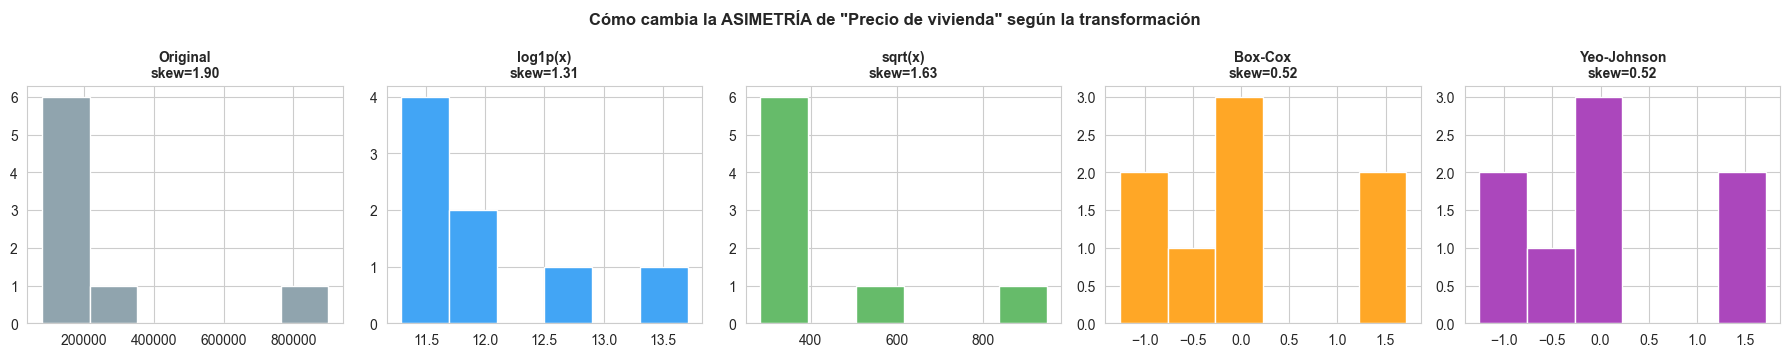

A medida que la asimetría (skew) se acerca a 0, la distribución se vuelve más simétrica.
Original: skew=1.90  →  la más asimétrica de todas.


In [11]:
# ── Figura: comparación visual de las 4 transformaciones sobre la MISMA variable ──
# Usamos los precios de viviendas del ejemplo de Box-Cox para comparar todas juntas
vivienda_precio = precios['Precio'].values

transf = {
    'Original':     vivienda_precio,
    'log1p(x)':     np.log1p(vivienda_precio),
    'sqrt(x)':      np.sqrt(vivienda_precio),
    'Box-Cox':      PowerTransformer(method='box-cox').fit_transform(vivienda_precio.reshape(-1,1)).flatten(),
    'Yeo-Johnson':  PowerTransformer(method='yeo-johnson').fit_transform(vivienda_precio.reshape(-1,1)).flatten(),
}
colores_t = ['#90A4AE', '#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
for ax, (nombre, datos), color in zip(axes, transf.items(), colores_t):
    ax.hist(datos, bins=6, color=color, edgecolor='white')
    sk = stats.skew(datos)
    ax.set_title(f'{nombre}\nskew={sk:.2f}', fontsize=10, fontweight='bold')

plt.suptitle('Cómo cambia la ASIMETRÍA de "Precio de vivienda" según la transformación', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('A medida que la asimetría (skew) se acerca a 0, la distribución se vuelve más simétrica.')
print(f"Original: skew={stats.skew(transf['Original']):.2f}  →  la más asimétrica de todas.")

---
## Winsorizing / Capping


**Definición:** Recortar los valores extremos (outliers) al percentil límite definido,  
**sin eliminar el registro**. Los valores que superan el umbral se reemplazan por el umbral.

**Ejemplo:** Si P99 = 10,000, cualquier valor mayor se reemplaza por 10,000.

**Cuándo usar:**
- Outliers **genuinos** que distorsionan el modelo sin aportar información
- Cuando no se quieren perder registros
- Antes de StandardScaler para evitar puntuaciones Z extremas

**Cuándo NO usar:**
- Si los outliers son los casos más importantes (detección de fraude, anomalías)
- Con árboles de decisión (son robustos a outliers)


In [12]:
# Tiempos de respuesta de un servidor (en ms)
df_tiempo = pd.DataFrame({
    'Petición': ['P1','P2','P3','P4','P5','P6','P7','P8','P9','P10'],
    'Tiempo_ms': [120, 135, 128, 118, 125, 130, 122, 5000, 119, 132]
    #                                                   ^^^^ outlier claro
})

print('ANTES (P8 tiene tiempo de 5000ms — outlier extremo):')
print(df_tiempo)
print(f'\nMedia original:  {df_tiempo["Tiempo_ms"].mean():.1f} ms')
print(f'Mediana original: {df_tiempo["Tiempo_ms"].median():.1f} ms')

# Winsorizar al percentil 90 superior
p90 = df_tiempo['Tiempo_ms'].quantile(0.90)
df_win = df_tiempo.copy()
df_win['Tiempo_ms_win'] = df_win['Tiempo_ms'].clip(upper=p90)

print(f'\nPercentil 90 = {p90:.1f} ms — todos los valores superiores se recortan a este valor')
print('\nDESPUÉS (winsorizing al P90):')
print(df_win)
print(f'\nMedia tras winsorizing:  {df_win["Tiempo_ms_win"].mean():.1f} ms')
print(f'Registros eliminados: 0 (el registro P8 sigue existiendo, solo con valor recortado)')

ANTES (P8 tiene tiempo de 5000ms — outlier extremo):
  Petición  Tiempo_ms
0       P1        120
1       P2        135
2       P3        128
3       P4        118
4       P5        125
5       P6        130
6       P7        122
7       P8       5000
8       P9        119
9      P10        132

Media original:  612.9 ms
Mediana original: 126.5 ms

Percentil 90 = 621.5 ms — todos los valores superiores se recortan a este valor

DESPUÉS (winsorizing al P90):
  Petición  Tiempo_ms  Tiempo_ms_win
0       P1        120          120.0
1       P2        135          135.0
2       P3        128          128.0
3       P4        118          118.0
4       P5        125          125.0
5       P6        130          130.0
6       P7        122          122.0
7       P8       5000          621.5
8       P9        119          119.0
9      P10        132          132.0

Media tras winsorizing:  175.0 ms
Registros eliminados: 0 (el registro P8 sigue existiendo, solo con valor recortado)


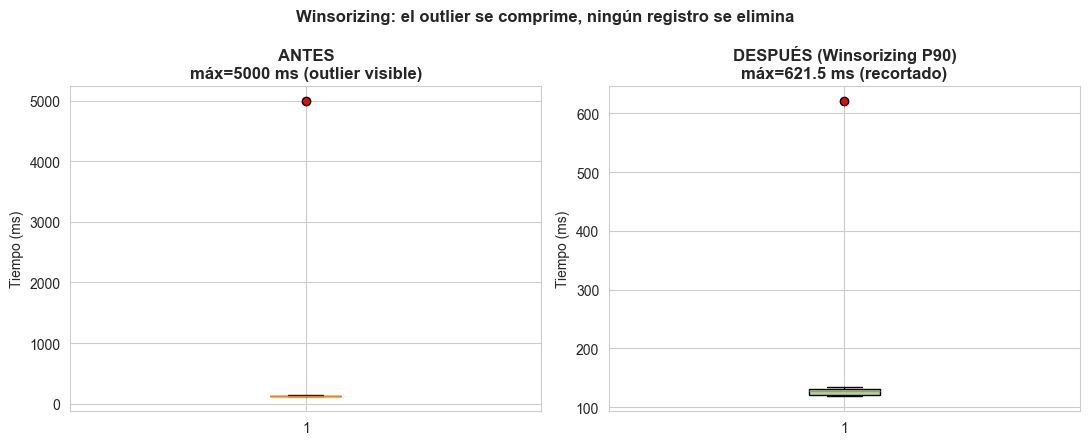

In [13]:
# ── Figura: Winsorizing — boxplot antes y después ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].boxplot(df_tiempo['Tiempo_ms'], patch_artist=True,
                boxprops=dict(facecolor='#EF9A9A'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
axes[0].set_title(f'ANTES\nmáx={df_tiempo["Tiempo_ms"].max():.0f} ms (outlier visible)', fontweight='bold')
axes[0].set_ylabel('Tiempo (ms)')

axes[1].boxplot(df_win['Tiempo_ms_win'], patch_artist=True,
                boxprops=dict(facecolor='#A5D6A7'),
                flierprops=dict(marker='o', markerfacecolor='red', markersize=6))
axes[1].set_title(f'DESPUÉS (Winsorizing P90)\nmáx={df_win["Tiempo_ms_win"].max():.1f} ms (recortado)', fontweight='bold')
axes[1].set_ylabel('Tiempo (ms)')

plt.suptitle('Winsorizing: el outlier se comprime, ningún registro se elimina', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Quantile Transformation


**Definición:** Transforma los valores de una variable para que sigan una distribución  
**uniforme** [0,1] o **normal** estándar, usando los cuantiles de los datos originales.

**Cómo funciona:** Mapea el rango de los datos originales al rango de la distribución objetivo.  
El valor más bajo va a 0 (o -∞ en normal), el más alto va a 1 (o +∞ en normal).

**Cuándo usar:**
- Cuando ninguna transformación paramétrica (log, Box-Cox) logra normalizar
- Datos con distribuciones muy irregulares o multimodales
- Los outliers se comprimen automáticamente al extremo del rango

**Cuándo NO usar:**
- Cuando la interpretabilidad del valor original es importante
- Con árboles de decisión (no lo necesitan)
- Con datos muy pequeños (el mapeo por cuantiles es poco estable)


In [14]:
# Ingresos con distribución irregular
ingresos = pd.DataFrame({
    'Persona':  ['A','B','C','D','E','F','G','H'],
    'Ingreso':  [500, 520, 530, 540, 560, 3000, 8000, 50000]
    #            ← muchos agrupados aquí →    ← pocos pero muy altos →
})

print('ANTES (mayoría entre 500-560, pero hay valores hasta 50000):')
print(ingresos)

qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=42)
qt_normal  = QuantileTransformer(output_distribution='normal', random_state=42)

ingresos['Quantile_Uniforme'] = qt_uniform.fit_transform(ingresos[['Ingreso']]).round(3)
ingresos['Quantile_Normal']   = qt_normal.fit_transform(ingresos[['Ingreso']]).round(3)

print('\nDESPUÉS:')
print(ingresos)

print('\nObservación (salida uniforme):')
print('  Los 8 valores quedan distribuidos uniformemente de 0 a 1.')
print('  500 → 0.0,  50000 → 1.0')
print('  Las personas cercanas entre sí (500-560) quedan separadas porque en esa zona hay más datos.')

ANTES (mayoría entre 500-560, pero hay valores hasta 50000):
  Persona  Ingreso
0       A      500
1       B      520
2       C      530
3       D      540
4       E      560
5       F     3000
6       G     8000
7       H    50000

DESPUÉS:
  Persona  Ingreso  Quantile_Uniforme  Quantile_Normal
0       A      500              0.000           -5.199
1       B      520              0.143           -1.068
2       C      530              0.286           -0.566
3       D      540              0.429           -0.180
4       E      560              0.571            0.180
5       F     3000              0.714            0.566
6       G     8000              0.857            1.068
7       H    50000              1.000            5.199

Observación (salida uniforme):
  Los 8 valores quedan distribuidos uniformemente de 0 a 1.
  500 → 0.0,  50000 → 1.0
  Las personas cercanas entre sí (500-560) quedan separadas porque en esa zona hay más datos.


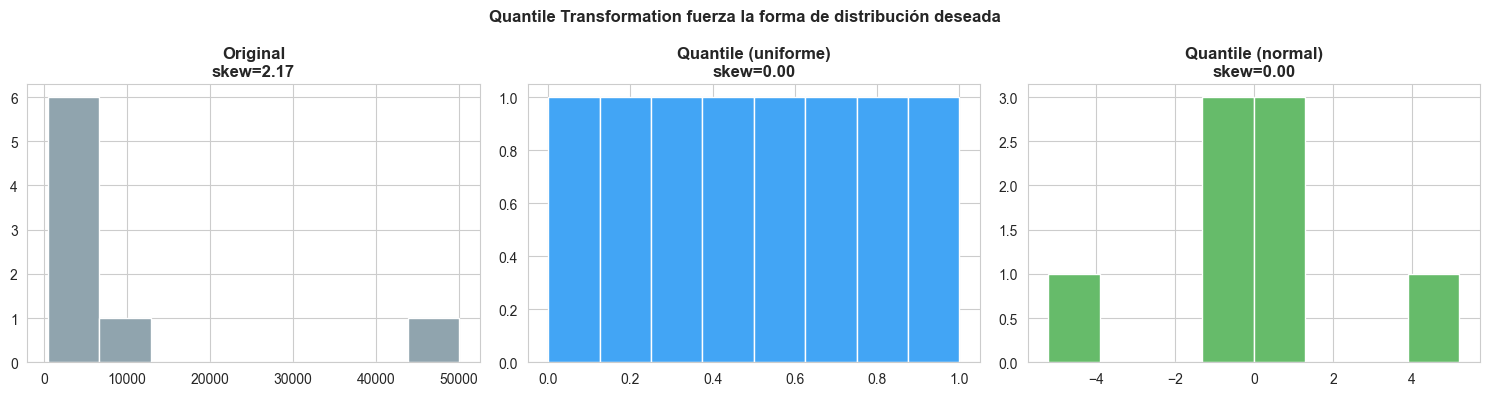

In [15]:
# ── Figura: Quantile Transformation — histograma antes y después ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ingresos['Ingreso'], bins=8, color='#90A4AE', edgecolor='white')
axes[0].set_title(f'Original\nskew={stats.skew(ingresos["Ingreso"]):.2f}', fontweight='bold')

axes[1].hist(ingresos['Quantile_Uniforme'], bins=8, color='#42A5F5', edgecolor='white')
axes[1].set_title(f'Quantile (uniforme)\nskew={stats.skew(ingresos["Quantile_Uniforme"]):.2f}', fontweight='bold')

axes[2].hist(ingresos['Quantile_Normal'], bins=8, color='#66BB6A', edgecolor='white')
axes[2].set_title(f'Quantile (normal)\nskew={stats.skew(ingresos["Quantile_Normal"]):.2f}', fontweight='bold')

plt.suptitle('Quantile Transformation fuerza la forma de distribución deseada', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# CATEGORÍA 3 · Creación y Discretización de Variables

## El problema que resuelve esta categoría

Las categorías 1 y 2 modifican variables que **ya existen**. Esta categoría es distinta:  
se trata de **crear variables nuevas** — a veces convirtiendo una continua en categorías (discretización),  
a veces combinando variables existentes (agregación), y a veces extrayendo información oculta  
en un dato complejo como una fecha.

El hilo conductor: en todos los casos, terminamos con **columnas nuevas** que no existían en el dataset original.


## Discretización


**Definición:** Convertir una variable numérica continua en **categorías discretas**  
(intervalos o rangos). Transforma números en etiquetas.

**¿Por qué?**
- Algunos algoritmos (Naive Bayes) trabajan mejor con categóricas
- Reduce el impacto de outliers (el outlier cae en el bin más extremo)
- Captura relaciones **no lineales por tramos** (ej: riesgo médico por grupo de edad)


### Equal Width Discretization — pd.cut()

Divide el rango de la variable en **intervalos de igual tamaño**.

- Sencillo de interpretar: cada bin abarca el mismo rango de valores
- Problema: si los datos no están distribuidos uniformemente, algunos bins quedan vacíos o con muy pocos datos


In [16]:
# Edades de clientes (queremos crear grupos de edad)
df_clientes = pd.DataFrame({
    'Cliente': ['C1','C2','C3','C4','C5','C6','C7','C8'],
    'Edad':    [8,   22,  35,  47,  16,  63,  55,  29]
})

print('ANTES:')
print(df_clientes)

# Discretización en 4 bins de igual ancho con etiquetas descriptivas
df_clientes['Grupo_Edad'] = pd.cut(
    df_clientes['Edad'],
    bins=4,
    labels=['Niño/Joven', 'Adulto Joven', 'Adulto', 'Senior']
)

print('\nDESPUÉS (pd.cut — 4 intervalos de igual ancho):')
print(df_clientes)

print('\nDistribución:')
print(df_clientes['Grupo_Edad'].value_counts().sort_index())

ANTES:
  Cliente  Edad
0      C1     8
1      C2    22
2      C3    35
3      C4    47
4      C5    16
5      C6    63
6      C7    55
7      C8    29

DESPUÉS (pd.cut — 4 intervalos de igual ancho):
  Cliente  Edad    Grupo_Edad
0      C1     8    Niño/Joven
1      C2    22  Adulto Joven
2      C3    35  Adulto Joven
3      C4    47        Adulto
4      C5    16    Niño/Joven
5      C6    63        Senior
6      C7    55        Senior
7      C8    29  Adulto Joven

Distribución:
Grupo_Edad
Niño/Joven      2
Adulto Joven    3
Adulto          1
Senior          2
Name: count, dtype: int64


### Equal Frequency Discretization — pd.qcut()

Divide los datos en bins con **igual número de registros** en cada uno (basado en cuantiles).

- Cada bin tiene aproximadamente la misma cantidad de datos
- Los bins tienen anchos distintos dependiendo de la distribución
- Preferible cuando la distribución es muy asimétrica


In [17]:
# Los mismos clientes pero usando qcut (igual frecuencia)
df_q = df_clientes[['Cliente','Edad']].copy()

# Con pd.cut (igual ancho) vs pd.qcut (igual frecuencia)
df_q['EqualWidth']     = pd.cut(df_q['Edad'],  bins=4, labels=['G1','G2','G3','G4'])
df_q['EqualFrequency'] = pd.qcut(df_q['Edad'], q=4,   labels=['Q1','Q2','Q3','Q4'])

print('Comparación de Equal Width vs Equal Frequency:')
print(df_q)

print('\nDistribución Equal Width:')
print(df_q['EqualWidth'].value_counts().sort_index())

print('\nDistribución Equal Frequency (cada cuartil tiene 2 registros):')
print(df_q['EqualFrequency'].value_counts().sort_index())

print('\nObservación: Equal Frequency garantiza bins balanceados (útil para árboles de decisión).')

Comparación de Equal Width vs Equal Frequency:
  Cliente  Edad EqualWidth EqualFrequency
0      C1     8         G1             Q1
1      C2    22         G2             Q2
2      C3    35         G2             Q3
3      C4    47         G3             Q3
4      C5    16         G1             Q1
5      C6    63         G4             Q4
6      C7    55         G4             Q4
7      C8    29         G2             Q2

Distribución Equal Width:
EqualWidth
G1    2
G2    3
G3    1
G4    2
Name: count, dtype: int64

Distribución Equal Frequency (cada cuartil tiene 2 registros):
EqualFrequency
Q1    2
Q2    2
Q3    2
Q4    2
Name: count, dtype: int64

Observación: Equal Frequency garantiza bins balanceados (útil para árboles de decisión).


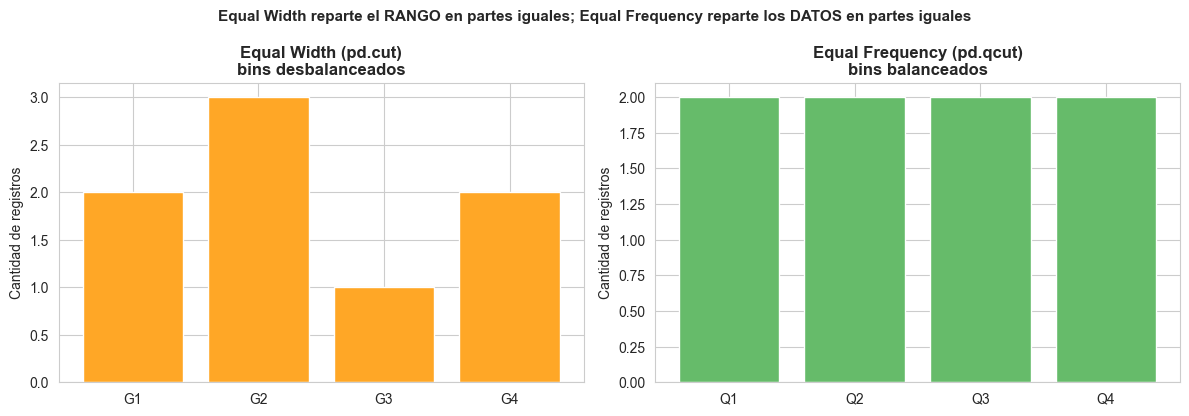

In [18]:
# ── Figura: Equal Width vs Equal Frequency — distribución de los bins ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

conteo_ew = df_q['EqualWidth'].value_counts().sort_index()
conteo_ef = df_q['EqualFrequency'].value_counts().sort_index()

axes[0].bar(conteo_ew.index.astype(str), conteo_ew.values, color='#FFA726', edgecolor='white')
axes[0].set_title('Equal Width (pd.cut)\nbins desbalanceados', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')

axes[1].bar(conteo_ef.index.astype(str), conteo_ef.values, color='#66BB6A', edgecolor='white')
axes[1].set_title('Equal Frequency (pd.qcut)\nbins balanceados', fontweight='bold')
axes[1].set_ylabel('Cantidad de registros')

plt.suptitle('Equal Width reparte el RANGO en partes iguales; Equal Frequency reparte los DATOS en partes iguales',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Binarización


**Definición:** Caso especial de discretización con **solo dos categorías**: 0 y 1,  
basada en un **umbral** definido por el analista.

**x' = 1 si x >= umbral; x' = 0 si x < umbral**

**Cuándo usar:**
- Crear variables de **riesgo** o **condición**: ¿la temperatura supera los 37.5°C?
- Simplificar una variable cuando solo importa si está por encima o por debajo de un valor
- Con conocimiento del dominio (un médico sabe que glucosa >= 126 indica diabetes)


In [19]:
# Resultado de análisis de glucosa en sangre
df_glucosa = pd.DataFrame({
    'Paciente':    ['P1', 'P2', 'P3', 'P4', 'P5', 'P6'],
    'Glucosa_mgdl': [95,  130, 115,  160,  88,   142]
})

UMBRAL_DIABETES = 126  # mg/dL — valor clínico establecido

print('ANTES:')
print(df_glucosa)

df_glucosa['Diabetes'] = (df_glucosa['Glucosa_mgdl'] >= UMBRAL_DIABETES).astype(int)

print(f'\nDESPUÉS (binarización con umbral = {UMBRAL_DIABETES} mg/dL):')
print(df_glucosa)

print('\nInterpretación:')
print(f'  Diabetes = 1 → glucosa ≥ {UMBRAL_DIABETES} (indica diabetes según criterio médico)')
print(f'  Diabetes = 0 → glucosa < {UMBRAL_DIABETES} (valores normales o pre-diabéticos)')

ANTES:
  Paciente  Glucosa_mgdl
0       P1            95
1       P2           130
2       P3           115
3       P4           160
4       P5            88
5       P6           142

DESPUÉS (binarización con umbral = 126 mg/dL):
  Paciente  Glucosa_mgdl  Diabetes
0       P1            95         0
1       P2           130         1
2       P3           115         0
3       P4           160         1
4       P5            88         0
5       P6           142         1

Interpretación:
  Diabetes = 1 → glucosa ≥ 126 (indica diabetes según criterio médico)
  Diabetes = 0 → glucosa < 126 (valores normales o pre-diabéticos)


---
## Polynomial Features


**Definición:** Crear nuevas variables elevando las originales a potencias e incluyendo  
**términos de interacción** entre pares de variables.

Con variables [A, B] y grado 2 se generan: **[A, B, A², AB, B²]**

**¿Por qué?** Un modelo lineal con estas nuevas variables puede capturar relaciones  
curvilíneas sin cambiar el tipo de modelo.

**Cuándo usar:**
- Regresión lineal cuando la relación con el objetivo es cuadrática o cúbica
- Cuando hay **interacciones** conocidas entre variables (el efecto de A depende de B)

**Cuándo NO usar:**
- Con muchas variables: el número de features crece exponencialmente
- Árboles de decisión (capturan interacciones internamente)


In [20]:
# Área de una parcela y exposición solar → impacto en el precio de un cultivo
df_cultivo = pd.DataFrame({
    'Area_ha':    [1.0, 2.0, 3.0, 4.0],
    'Solar_horas':[4,   6,   5,   8]
})

print('ANTES (2 variables originales):')
print(df_cultivo)

poly = PolynomialFeatures(degree=2, include_bias=False)
resultado = pd.DataFrame(
    poly.fit_transform(df_cultivo),
    columns=poly.get_feature_names_out(['Area_ha', 'Solar_horas'])
)

print(f'\nDESPUÉS (PolynomialFeatures grado=2 → {resultado.shape[1]} columnas):')
print(resultado)

print('\nSignificado de cada columna nueva:')
print('  Area_ha^2        → captura relación cuadrática entre área y precio')
print('  Area_ha Solar_horas → INTERACCIÓN: una parcela grande Y con mucho sol vale más que la suma')
print('  Solar_horas^2    → captura rendimientos decrecientes de la luz solar')

ANTES (2 variables originales):
   Area_ha  Solar_horas
0      1.0            4
1      2.0            6
2      3.0            5
3      4.0            8

DESPUÉS (PolynomialFeatures grado=2 → 5 columnas):
   Area_ha  Solar_horas  Area_ha^2  Area_ha Solar_horas  Solar_horas^2
0      1.0          4.0        1.0                  4.0           16.0
1      2.0          6.0        4.0                 12.0           36.0
2      3.0          5.0        9.0                 15.0           25.0
3      4.0          8.0       16.0                 32.0           64.0

Significado de cada columna nueva:
  Area_ha^2        → captura relación cuadrática entre área y precio
  Area_ha Solar_horas → INTERACCIÓN: una parcela grande Y con mucho sol vale más que la suma
  Solar_horas^2    → captura rendimientos decrecientes de la luz solar


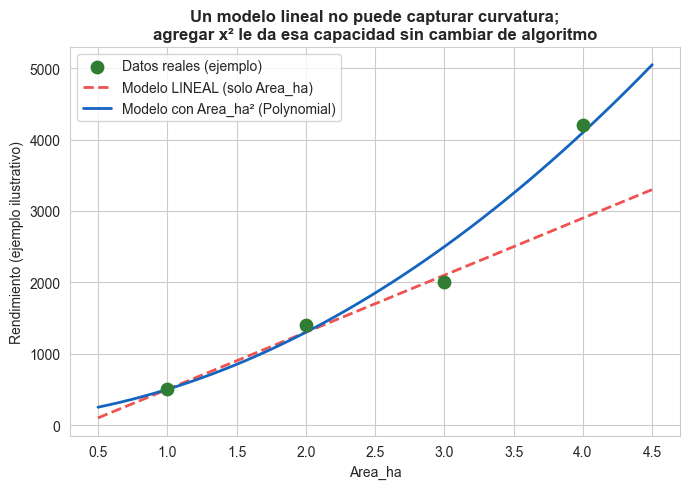

In [21]:
# ── Figura: por qué Polynomial Features ayuda — relación no lineal ──
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(df_cultivo['Area_ha'], [500, 1400, 2000, 4200], s=80, color='#2E7D32', zorder=3, label='Datos reales (ejemplo)')

x_line = np.linspace(0.5, 4.5, 50)
# Ajuste lineal simple vs cuadrático simple (solo ilustrativo)
y_lineal = 500 + 800*(x_line-1)
y_cuadratico = 500 + 200*(x_line-1)**2 + 600*(x_line-1)

ax.plot(x_line, y_lineal, '--', color='#EF5350', linewidth=2, label='Modelo LINEAL (solo Area_ha)')
ax.plot(x_line, y_cuadratico, '-', color='#1565C0', linewidth=2, label='Modelo con Area_ha² (Polynomial)')

ax.set_xlabel('Area_ha')
ax.set_ylabel('Rendimiento (ejemplo ilustrativo)')
ax.set_title('Un modelo lineal no puede capturar curvatura;\nagregar x² le da esa capacidad sin cambiar de algoritmo', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## Agregación y Feature Engineering


**Definición:** Crear nuevas variables combinando o transformando las existentes  
usando **conocimiento del dominio** para capturar información que las variables individuales  
no capturan por sí solas.

Esta técnica suele tener el mayor impacto en la calidad del modelo, superando incluso  
la elección del algoritmo.

**Tipos de feature engineering:**
- **Suma / combinación:** área total = sala + cocina + habitaciones
- **Ratio / proporción:** precio por metro cuadrado
- **Diferencia:** antigüedad = año actual - año de construcción
- **Indicadores binarios:** ¿tiene garaje? ¿es casa nueva?
- **Interacciones:** calidad × área (una casa grande Y buena vale mucho más)


In [22]:
# Dataset de casas con medidas de cada habitación
# Diseñado para que el PRECIO dependa de la combinación área × calidad
# (una casa grande Y de alta calidad es desproporcionadamente más cara —
#  efecto "mansión de lujo" — ni el área sola ni la calidad sola lo explican bien)
df_casa = pd.DataFrame({
    'Casa':            ['H1', 'H2', 'H3', 'H4', 'H5', 'H6'],
    'Sala_m2':         [12,   12,   35,   35,   22,   26],
    'Cocina_m2':       [8,    8,    18,   18,   12,   14],
    'Habitaciones_m2': [30,   30,   127,  127,  66,   90],
    'Garaje_m2':       [0,    0,    25,   25,   15,   0],
    'Ano_Construccion':[1995, 2015, 1998, 2020, 2008, 2001],
    'Calidad':         [3,    9,    3,    9,    6,    5],   # 1-10
    'Precio':          [32000, 87000, 113000, 320000, 121000, 92000]
})

print('DATASET ORIGINAL:')
print(df_casa)
print()
print('Observa: H1 y H2 tienen la MISMA área pero distinta calidad → precio distinto')
print('         H3 y H4 tienen la MISMA área pero distinta calidad → precio MUY distinto')
print('         H4 (grande Y de alta calidad) es desproporcionadamente la más cara')


DATASET ORIGINAL:
  Casa  Sala_m2  Cocina_m2  Habitaciones_m2  Garaje_m2  Ano_Construccion  \
0   H1       12          8               30          0              1995   
1   H2       12          8               30          0              2015   
2   H3       35         18              127         25              1998   
3   H4       35         18              127         25              2020   
4   H5       22         12               66         15              2008   
5   H6       26         14               90          0              2001   

   Calidad  Precio  
0        3   32000  
1        9   87000  
2        3  113000  
3        9  320000  
4        6  121000  
5        5   92000  

Observa: H1 y H2 tienen la MISMA área pero distinta calidad → precio distinto
         H3 y H4 tienen la MISMA área pero distinta calidad → precio MUY distinto
         H4 (grande Y de alta calidad) es desproporcionadamente la más cara


In [23]:
# ── Crear nuevas variables ──
df_fe = df_casa.copy()

# 1. SUMA: área total (más representativa que cada área por separado)
df_fe['Area_Total_m2'] = df_fe['Sala_m2'] + df_fe['Cocina_m2'] + df_fe['Habitaciones_m2']

# 2. RATIO: precio por metro cuadrado
df_fe['Precio_m2'] = (df_fe['Precio'] / df_fe['Area_Total_m2']).round(0)

# 3. DIFERENCIA: antigüedad de la casa
df_fe['Antiguedad_anos'] = 2024 - df_fe['Ano_Construccion']

# 4. INDICADOR BINARIO: ¿tiene garaje?
df_fe['Tiene_Garaje'] = (df_fe['Garaje_m2'] > 0).astype(int)

# 5. INTERACCIÓN: calidad × área (casas grandes Y de calidad valen mucho más)
df_fe['Calidad_x_Area'] = df_fe['Calidad'] * df_fe['Area_Total_m2']

print('NUEVAS VARIABLES CREADAS:')
cols_nuevas = ['Casa','Area_Total_m2','Precio_m2','Antiguedad_anos','Tiene_Garaje','Calidad_x_Area','Precio']
print(df_fe[cols_nuevas])

# Correlación de las variables nuevas vs el precio
print('\nCorrelación con Precio (variable objetivo):')
vars_comp = ['Sala_m2','Area_Total_m2','Antiguedad_anos','Calidad','Calidad_x_Area']
correlaciones = {v: df_fe[v].corr(df_fe['Precio']) for v in vars_comp}
for v, r in sorted(correlaciones.items(), key=lambda x: -abs(x[1])):
    print(f'  {v:<22} r = {r:+.3f}')

mejor_individual = max(
    (v for v in correlaciones if v != 'Calidad_x_Area'),
    key=lambda v: abs(correlaciones[v])
)
print(f'\n→ Calidad_x_Area (r={correlaciones["Calidad_x_Area"]:+.3f}) supera a la mejor variable')
print(f'  individual, {mejor_individual} (r={correlaciones[mejor_individual]:+.3f}).')
print('  Ninguna variable por separado explica bien el precio: se necesita la interacción.')


NUEVAS VARIABLES CREADAS:
  Casa  Area_Total_m2  Precio_m2  Antiguedad_anos  Tiene_Garaje  \
0   H1             50      640.0               29             0   
1   H2             50     1740.0                9             0   
2   H3            180      628.0               26             1   
3   H4            180     1778.0                4             1   
4   H5            100     1210.0               16             1   
5   H6            130      708.0               23             0   

   Calidad_x_Area  Precio  
0             150   32000  
1             450   87000  
2             540  113000  
3            1620  320000  
4             600  121000  
5             650   92000  

Correlación con Precio (variable objetivo):
  Calidad_x_Area         r = +0.987
  Antiguedad_anos        r = -0.744
  Sala_m2                r = +0.686
  Area_Total_m2          r = +0.683
  Calidad                r = +0.609

→ Calidad_x_Area (r=+0.987) supera a la mejor variable
  individual, Antiguedad_an

In [24]:
# ── Agregación estadística por grupo ──
# Calcular estadísticas por barrio (útil cuando hay una variable de agrupación)
df_barrios = pd.DataFrame({
    'Casa':   ['H1','H2','H3','H4','H5','H6','H7','H8'],
    'Barrio': ['Norte','Norte','Sur','Sur','Centro','Centro','Norte','Sur'],
    'Area':   [80, 95, 60, 55, 120, 135, 85, 70],
    'Precio': [150000,170000,90000,85000,250000,280000,160000,95000]
})

print('Dataset original:')
print(df_barrios)

# Agregar estadísticas del barrio como nuevas features
stats_barrio = df_barrios.groupby('Barrio')['Precio'].agg(['mean','std','min','max'])
stats_barrio.columns = ['Barrio_Precio_Mean','Barrio_Precio_Std','Barrio_Precio_Min','Barrio_Precio_Max']

df_agg = df_barrios.merge(stats_barrio, on='Barrio')

# Feature: ¿es esta casa más cara o más barata que el promedio de su barrio?
df_agg['Vs_Promedio_Barrio'] = df_agg['Precio'] - df_agg['Barrio_Precio_Mean']

print('\nDespués de agregar estadísticas del barrio:')
print(df_agg[['Casa','Barrio','Precio','Barrio_Precio_Mean','Vs_Promedio_Barrio']])

Dataset original:
  Casa  Barrio  Area  Precio
0   H1   Norte    80  150000
1   H2   Norte    95  170000
2   H3     Sur    60   90000
3   H4     Sur    55   85000
4   H5  Centro   120  250000
5   H6  Centro   135  280000
6   H7   Norte    85  160000
7   H8     Sur    70   95000

Después de agregar estadísticas del barrio:
  Casa  Barrio  Precio  Barrio_Precio_Mean  Vs_Promedio_Barrio
0   H1   Norte  150000            160000.0            -10000.0
1   H2   Norte  170000            160000.0             10000.0
2   H3     Sur   90000             90000.0                 0.0
3   H4     Sur   85000             90000.0             -5000.0
4   H5  Centro  250000            265000.0            -15000.0
5   H6  Centro  280000            265000.0             15000.0
6   H7   Norte  160000            160000.0                 0.0
7   H8     Sur   95000             90000.0              5000.0


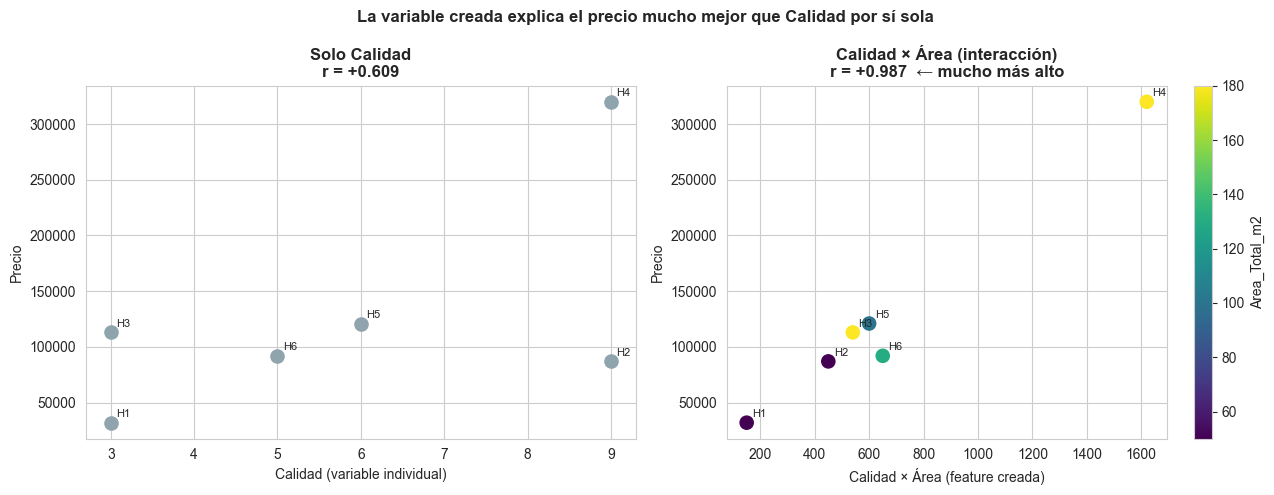

In [25]:
# ── Figura: Feature Engineering en acción — variable individual vs interacción ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df_fe['Calidad'], df_fe['Precio'], s=90, color='#90A4AE')
for _, row in df_fe.iterrows():
    axes[0].annotate(row['Casa'], (row['Calidad'], row['Precio']), fontsize=8, xytext=(4,4), textcoords='offset points')
r_calidad = df_fe['Calidad'].corr(df_fe['Precio'])
axes[0].set_xlabel('Calidad (variable individual)')
axes[0].set_ylabel('Precio')
axes[0].set_title(f'Solo Calidad\nr = {r_calidad:+.3f}', fontweight='bold')

sc = axes[1].scatter(df_fe['Calidad_x_Area'], df_fe['Precio'], s=90, c=df_fe['Area_Total_m2'], cmap='viridis')
for _, row in df_fe.iterrows():
    axes[1].annotate(row['Casa'], (row['Calidad_x_Area'], row['Precio']), fontsize=8, xytext=(4,4), textcoords='offset points')
plt.colorbar(sc, ax=axes[1], label='Area_Total_m2')
r_interaccion = df_fe['Calidad_x_Area'].corr(df_fe['Precio'])
axes[1].set_xlabel('Calidad × Área (feature creada)')
axes[1].set_ylabel('Precio')
axes[1].set_title(f'Calidad × Área (interacción)\nr = {r_interaccion:+.3f}  ← mucho más alto', fontweight='bold')

plt.suptitle('La variable creada explica el precio mucho mejor que Calidad por sí sola', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Extracción de Features de Fecha/Hora


**Definición:** Una fecha como `2024-11-15 14:30:00` no puede usarse directamente en un modelo.  
Se descompone en sus **componentes numéricos** que sí pueden procesarse.

**Componentes comunes:**
- `año`, `mes`, `día`, `hora`, `minuto`
- `día de la semana` (0=Lunes, 6=Domingo)
- `trimestre`
- `¿es fin de semana?` (binario)
- `¿es festivo?` (binario, requiere librería adicional)
- `días desde un evento de referencia` (variable continua)

**Cuándo usar:**
- Ventas por temporada
- Patrones de uso horario
- Series temporales en general


In [26]:
# Registro de compras en una tienda online
df_compras = pd.DataFrame({
    'ID':    [1, 2, 3, 4, 5, 6],
    'Fecha': ['2024-12-24 09:15:00',  # Nochebuena, mañana
              '2024-12-25 15:30:00',  # Navidad, tarde
              '2024-01-02 08:00:00',  # Martes, mañana
              '2024-06-15 22:45:00',  # Sábado, noche
              '2024-11-29 18:00:00',  # Black Friday
              '2024-03-18 11:30:00'], # Lunes normal
    'Monto': [250, 180, 90, 320, 450, 120]
})
df_compras['Fecha'] = pd.to_datetime(df_compras['Fecha'])

print('ANTES:')
print(df_compras)

df_compras['Ano']           = df_compras['Fecha'].dt.year
df_compras['Mes']           = df_compras['Fecha'].dt.month
df_compras['Dia']           = df_compras['Fecha'].dt.day
df_compras['Hora']          = df_compras['Fecha'].dt.hour
df_compras['DiaSemana']     = df_compras['Fecha'].dt.dayofweek   # 0=Lunes
df_compras['NombreDia']     = df_compras['Fecha'].dt.day_name()
df_compras['Trimestre']     = df_compras['Fecha'].dt.quarter
df_compras['EsFinSemana']   = (df_compras['DiaSemana'] >= 5).astype(int)
df_compras['EsNoche']       = (df_compras['Hora'] >= 20).astype(int)

print('\nDESPUÉS (features extraídas):')
print(df_compras[['ID','Fecha','Mes','Hora','DiaSemana','NombreDia','EsFinSemana','EsNoche','Monto']])

ANTES:
   ID               Fecha  Monto
0   1 2024-12-24 09:15:00    250
1   2 2024-12-25 15:30:00    180
2   3 2024-01-02 08:00:00     90
3   4 2024-06-15 22:45:00    320
4   5 2024-11-29 18:00:00    450
5   6 2024-03-18 11:30:00    120

DESPUÉS (features extraídas):
   ID               Fecha  Mes  Hora  DiaSemana  NombreDia  EsFinSemana  \
0   1 2024-12-24 09:15:00   12     9          1    Tuesday            0   
1   2 2024-12-25 15:30:00   12    15          2  Wednesday            0   
2   3 2024-01-02 08:00:00    1     8          1    Tuesday            0   
3   4 2024-06-15 22:45:00    6    22          5   Saturday            1   
4   5 2024-11-29 18:00:00   11    18          4     Friday            0   
5   6 2024-03-18 11:30:00    3    11          0     Monday            0   

   EsNoche  Monto  
0        0    250  
1        0    180  
2        0     90  
3        1    320  
4        0    450  
5        0    120  


---
# CATEGORÍA 4 · Codificación de Variables Categóricas

## El problema que resuelve esta categoría

Todo lo anterior (categorías 1-3) trabaja con **números**. Pero el mundo real está lleno de variables  
de **texto**: colores, países, niveles educativos, departamentos. Los algoritmos de Machine Learning  
solo entienden números, así que necesitamos **convertir texto en números de forma coherente**.

La decisión clave siempre es la misma: **¿la variable tiene orden (ordinal) o no (nominal)?**  
Esa pregunta determina cuál de las 6 técnicas siguientes es la correcta.


**Definición:** Convertir variables de texto o categorías en valores numéricos  
para que los algoritmos de Machine Learning puedan procesarlas.

**Regla fundamental:** El método de codificación depende de:
1. Si la variable es **ordinal** (tiene orden) o **nominal** (sin orden)
2. La **cardinalidad** (número de categorías distintas)
3. El **algoritmo** que se usará después


## Label Encoding

Asigna un número entero a cada categoría: A→0, B→1, C→2, etc.

**Cuándo usar:**
- Variables **ordinales** donde el orden sí importa
- **Árboles de decisión** y Random Forest (pueden manejar números arbitrarios)

**⚠ Cuándo NO usar:**
- Variables **nominales** en modelos lineales: el modelo asumirá que Azul (2) > Verde (1) > Rojo (0),  
  lo cual es falso para categorías sin orden natural.


In [27]:
# Color de camisetas (nominal — sin orden)
df_color = pd.DataFrame({
    'Camiseta': ['C1','C2','C3','C4','C5','C6'],
    'Color':    ['Rojo', 'Verde', 'Azul', 'Rojo', 'Verde', 'Azul']
})

print('ANTES:')
print(df_color)

le = LabelEncoder()
df_color['Color_Label'] = le.fit_transform(df_color['Color'])

print('\nDESPUÉS (Label Encoding):')
print(df_color)

print(f'\nMapeo asignado: {dict(zip(le.classes_, le.transform(le.classes_)))}')
print('\n⚠ Problema para modelos lineales:')
print('   El modelo podría interpretar: Azul (0) < Rojo (1) < Verde (2)')
print('   Esto NO tiene sentido para colores (no hay orden entre ellos).')
print('   → Para modelos lineales, usar One-Hot Encoding en este caso.')

ANTES:
  Camiseta  Color
0       C1   Rojo
1       C2  Verde
2       C3   Azul
3       C4   Rojo
4       C5  Verde
5       C6   Azul

DESPUÉS (Label Encoding):
  Camiseta  Color  Color_Label
0       C1   Rojo            1
1       C2  Verde            2
2       C3   Azul            0
3       C4   Rojo            1
4       C5  Verde            2
5       C6   Azul            0

Mapeo asignado: {'Azul': np.int64(0), 'Rojo': np.int64(1), 'Verde': np.int64(2)}

⚠ Problema para modelos lineales:
   El modelo podría interpretar: Azul (0) < Rojo (1) < Verde (2)
   Esto NO tiene sentido para colores (no hay orden entre ellos).
   → Para modelos lineales, usar One-Hot Encoding en este caso.


## One-Hot Encoding

Crea una **columna binaria por cada categoría**. Solo una columna tiene 1, el resto tiene 0.

**Cuándo usar:**
- Variables **nominales** con pocas categorías (< ~15)
- Regresión lineal, logística, SVM, redes neuronales

**Consideraciones:**
- Con N categorías se crean N-1 columnas (se elimina una para evitar multicolinealidad)
- Con muchas categorías, el número de columnas puede ser muy grande (problema de dimensionalidad)


In [28]:
# Medio de transporte (nominal, sin orden)
df_transporte = pd.DataFrame({
    'Persona':    ['P1', 'P2', 'P3', 'P4', 'P5'],
    'Transporte': ['Auto', 'Bus', 'Bici', 'Bus', 'Auto']
})

print('ANTES:')
print(df_transporte)

# pd.get_dummies es la forma más directa en pandas
df_ohe = pd.get_dummies(df_transporte, columns=['Transporte'], prefix='Trans', drop_first=False)

# Convertir SOLO las columnas dummy (booleanas) a entero, no toda la tabla
cols_dummy = [c for c in df_ohe.columns if c.startswith('Trans_')]
df_ohe[cols_dummy] = df_ohe[cols_dummy].astype(int)

print('\nDESPUÉS (One-Hot Encoding):')
print(df_ohe)

print('\nInterpretación:')
print('  Cada fila tiene exactamente un 1 (en la columna de su categoría) y el resto 0.')
print('  No hay asunción de orden entre Auto, Bus y Bici.')
print('\nNota: drop_first=True eliminaría una columna para evitar multicolinealidad:')
df_ohe_drop = pd.get_dummies(df_transporte, columns=['Transporte'], prefix='Trans', drop_first=True)
cols_dummy_drop = [c for c in df_ohe_drop.columns if c.startswith('Trans_')]
df_ohe_drop[cols_dummy_drop] = df_ohe_drop[cols_dummy_drop].astype(int)
print(df_ohe_drop)


ANTES:
  Persona Transporte
0      P1       Auto
1      P2        Bus
2      P3       Bici
3      P4        Bus
4      P5       Auto

DESPUÉS (One-Hot Encoding):
  Persona  Trans_Auto  Trans_Bici  Trans_Bus
0      P1           1           0          0
1      P2           0           0          1
2      P3           0           1          0
3      P4           0           0          1
4      P5           1           0          0

Interpretación:
  Cada fila tiene exactamente un 1 (en la columna de su categoría) y el resto 0.
  No hay asunción de orden entre Auto, Bus y Bici.

Nota: drop_first=True eliminaría una columna para evitar multicolinealidad:
  Persona  Trans_Bici  Trans_Bus
0      P1           0          0
1      P2           0          1
2      P3           1          0
3      P4           0          1
4      P5           0          0


## Ordinal Encoding

Igual que Label Encoding pero el **orden se define explícitamente** por el analista.

**Cuándo usar:**
- Variables **ordinales** con orden claro: nivel educativo, talla, nivel de satisfacción
- A diferencia de Label Encoding, aquí el analista controla el orden


In [29]:
# Nivel de educación (ordinal — SÍ tiene orden natural)
df_edu = pd.DataFrame({
    'Persona':  ['Ana', 'Luis', 'María', 'Carlos', 'Pedro'],
    'Educacion': ['Universitario', 'Primaria', 'Secundaria', 'Maestría', 'Universitario']
})

print('ANTES:')
print(df_edu)

# Definir el orden explícitamente
orden = [['Primaria', 'Secundaria', 'Universitario', 'Maestría']]

oe = OrdinalEncoder(categories=orden)
df_edu['Educacion_Ordinal'] = oe.fit_transform(df_edu[['Educacion']]).astype(int)

print('\nDESPUÉS (Ordinal Encoding):')
print(df_edu)

print('\nMapeo (definido por el analista):')
for i, cat in enumerate(orden[0]):
    print(f'  {cat:<20} → {i}')
print('\n✓ El modelo SÍ puede interpretar que Maestría (3) > Universitario (2) > Secundaria (1)')

ANTES:
  Persona      Educacion
0     Ana  Universitario
1    Luis       Primaria
2   María     Secundaria
3  Carlos       Maestría
4   Pedro  Universitario

DESPUÉS (Ordinal Encoding):
  Persona      Educacion  Educacion_Ordinal
0     Ana  Universitario                  2
1    Luis       Primaria                  0
2   María     Secundaria                  1
3  Carlos       Maestría                  3
4   Pedro  Universitario                  2

Mapeo (definido por el analista):
  Primaria             → 0
  Secundaria           → 1
  Universitario        → 2
  Maestría             → 3

✓ El modelo SÍ puede interpretar que Maestría (3) > Universitario (2) > Secundaria (1)


## Target Encoding

Reemplaza cada categoría por la **media de la variable objetivo** dentro de esa categoría.

**Cuándo usar:**
- Variables con **muchas categorías** (alta cardinalidad): códigos postales, productos, IDs
- Regresión y clasificación

**⚠ Riesgo principal: Data Leakage**  
Si se calcula sobre todo el dataset, el modelo puede aprender el target directamente.  
**Solución:** Calcular el encoding solo sobre los datos de entrenamiento (nunca sobre los de prueba).


In [30]:
# Barrio y precio de casas
df_barrio = pd.DataFrame({
    'Casa':   ['C1','C2','C3','C4','C5','C6','C7','C8'],
    'Barrio':  ['Norte','Sur','Centro','Norte','Sur','Centro','Norte','Centro'],
    'Precio':  [150000, 80000, 250000, 165000, 75000, 240000, 155000, 260000]
})

print('ANTES:')
print(df_barrio)

# Target encoding manual: reemplazar por la media del precio por barrio
media_por_barrio = df_barrio.groupby('Barrio')['Precio'].mean()
df_barrio['Barrio_Target'] = df_barrio['Barrio'].map(media_por_barrio)

print('\nMedia de precio por barrio (el encoding):')
print(media_por_barrio.apply(lambda x: f'${x:,.0f}'))

print('\nDESPUÉS (Target Encoding):')
print(df_barrio)

print('\nInterpretación:')
print('  Centro  → $250,000 (promedio más alto → valor más alto)')
print('  Norte   → $156,667')
print('  Sur     → $77,500  (promedio más bajo → valor más bajo)')
print('  El modelo puede ahora cuantificar el efecto del barrio sobre el precio.')

ANTES:
  Casa  Barrio  Precio
0   C1   Norte  150000
1   C2     Sur   80000
2   C3  Centro  250000
3   C4   Norte  165000
4   C5     Sur   75000
5   C6  Centro  240000
6   C7   Norte  155000
7   C8  Centro  260000

Media de precio por barrio (el encoding):
Barrio
Centro    $250,000
Norte     $156,667
Sur        $77,500
Name: Precio, dtype: object

DESPUÉS (Target Encoding):
  Casa  Barrio  Precio  Barrio_Target
0   C1   Norte  150000  156666.666667
1   C2     Sur   80000   77500.000000
2   C3  Centro  250000  250000.000000
3   C4   Norte  165000  156666.666667
4   C5     Sur   75000   77500.000000
5   C6  Centro  240000  250000.000000
6   C7   Norte  155000  156666.666667
7   C8  Centro  260000  250000.000000

Interpretación:
  Centro  → $250,000 (promedio más alto → valor más alto)
  Norte   → $156,667
  Sur     → $77,500  (promedio más bajo → valor más bajo)
  El modelo puede ahora cuantificar el efecto del barrio sobre el precio.


## Frequency Encoding

Reemplaza cada categoría por su **frecuencia de aparición** en el dataset (proporción).

**Cuándo usar:**
- Cuando la **popularidad o rareza** de una categoría tiene valor predictivo
- Alta cardinalidad sin variable objetivo disponible

**Limitación:** Si dos categorías tienen la misma frecuencia, reciben el mismo valor
aunque sean semánticamente distintas.


In [31]:
# País de origen de clientes
df_pais = pd.DataFrame({
    'Cliente': ['C1','C2','C3','C4','C5','C6','C7','C8','C9','C10'],
    'Pais': ['España','México','España','Argentina','España','México','Colombia','España','México','España']
})

print('ANTES:')
print(df_pais)

# Frecuencia relativa de cada país
freq_map = df_pais['Pais'].value_counts(normalize=True)
df_pais['Pais_Freq'] = df_pais['Pais'].map(freq_map)

print('\nFrecuencias:')
print(freq_map.apply(lambda x: f'{x:.1%}'))

print('\nDESPUÉS (Frequency Encoding):')
print(df_pais)

print('\nInterpretación:')
print('  España aparece 5/10 veces → 0.5')
print('  México aparece 3/10 veces → 0.3')
print('  Argentina y Colombia: 1/10 → 0.1 cada uno')

ANTES:
  Cliente       Pais
0      C1     España
1      C2     México
2      C3     España
3      C4  Argentina
4      C5     España
5      C6     México
6      C7   Colombia
7      C8     España
8      C9     México
9     C10     España

Frecuencias:
Pais
España       50.0%
México       30.0%
Argentina    10.0%
Colombia     10.0%
Name: proportion, dtype: object

DESPUÉS (Frequency Encoding):
  Cliente       Pais  Pais_Freq
0      C1     España        0.5
1      C2     México        0.3
2      C3     España        0.5
3      C4  Argentina        0.1
4      C5     España        0.5
5      C6     México        0.3
6      C7   Colombia        0.1
7      C8     España        0.5
8      C9     México        0.3
9     C10     España        0.5

Interpretación:
  España aparece 5/10 veces → 0.5
  México aparece 3/10 veces → 0.3
  Argentina y Colombia: 1/10 → 0.1 cada uno


## Binary Encoding

Convierte la categoría a su **representación en binario** (bits).
Con N categorías, necesita aproximadamente `log₂(N)` columnas, mucho menos que One-Hot.

> Nota: la librería `category_encoders` reserva el código 0 para valores desconocidos/faltantes
> y empieza a codificar categorías desde 1, por lo que el número exacto de bits necesarios
> es `ceil(log2(N + 1))`.

**Cuándo usar:**
- Alta cardinalidad donde One-Hot generaría demasiadas columnas
- Como alternativa compacta a One-Hot

**Ejemplo:** 7 categorías → One-Hot necesita 6 columnas, Binary Encoding solo 3.


In [32]:
# Departamento de empleados (7 EMPLEADOS, cada uno de un departamento distinto)
# category_encoders reserva el código 0, así que para 7 categorías (códigos 1-7) usa 3 bits
df_depto = pd.DataFrame({
    'Empleado':     ['E1','E2','E3','E4','E5','E6','E7'],
    'Departamento': ['Ventas','RRHH','IT','Finanzas','Logística','Marketing','Legal']
})

print('ANTES (7 empleados, 7 departamentos distintos):')
print(df_depto)

if CE_OK:
    be = ce.BinaryEncoder(cols=['Departamento'])
    df_bin = be.fit_transform(df_depto)
    n_cols_binary = len([c for c in df_bin.columns if 'Departamento' in c])
    n_cats = df_depto['Departamento'].nunique()
    print(f'\nDESPUÉS (Binary Encoding — {n_cols_binary} columnas en lugar de {n_cats-1} de One-Hot):')
    print(df_bin)
else:
    print('\n(category_encoders no instalado — demostración manual del concepto):')
    cats = sorted(df_depto['Departamento'].unique())
    n_bits = len(bin(len(cats))) - 2   # log2(N+1) por el código reservado 0
    print(f'Con {len(cats)} categorías → One-Hot necesita {len(cats)-1} columnas, Binary solo {n_bits}:')
    for i, cat in enumerate(cats, start=1):   # 1-indexado, igual que category_encoders
        bits = format(i, f'0{n_bits}b')
        print(f'  {cat:<12} → código {i} → binario {bits}')


ANTES (7 empleados, 7 departamentos distintos):
  Empleado Departamento
0       E1       Ventas
1       E2         RRHH
2       E3           IT
3       E4     Finanzas
4       E5    Logística
5       E6    Marketing
6       E7        Legal

DESPUÉS (Binary Encoding — 3 columnas en lugar de 6 de One-Hot):
  Empleado  Departamento_0  Departamento_1  Departamento_2
0       E1               0               0               1
1       E2               0               1               0
2       E3               0               1               1
3       E4               1               0               0
4       E5               1               0               1
5       E6               1               1               0
6       E7               1               1               1


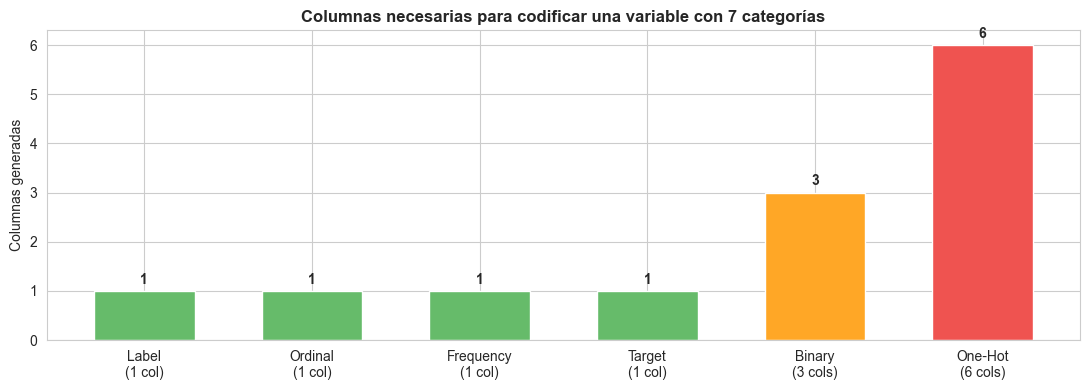

Regla práctica: < 5 categorías → One-Hot | 5-15 → One-Hot o Binary | > 15 → Target, Frequency o Binary


In [33]:
# ── Figura: número de columnas generadas por cada técnica ──
n_cats_ejemplo = 7  # como en el ejemplo de Binary Encoding
tecnicas_enc = ['Label\n(1 col)', 'Ordinal\n(1 col)', 'Frequency\n(1 col)', 'Target\n(1 col)',
                f'Binary\n(3 cols)', f'One-Hot\n({n_cats_ejemplo-1} cols)']
n_cols_enc = [1, 1, 1, 1, 3, n_cats_ejemplo-1]
colores_enc = ['#66BB6A']*4 + ['#FFA726', '#EF5350']

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(tecnicas_enc, n_cols_enc, color=colores_enc, edgecolor='white', width=0.6)
for bar, val in zip(bars, n_cols_enc):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.15, str(val), ha='center', fontweight='bold')
ax.set_ylabel('Columnas generadas')
ax.set_title(f'Columnas necesarias para codificar una variable con {n_cats_ejemplo} categorías', fontweight='bold')
plt.tight_layout()
plt.show()

print('Regla práctica: < 5 categorías → One-Hot | 5-15 → One-Hot o Binary | > 15 → Target, Frequency o Binary')

---
# CATEGORÍA 5 · Selección y Reducción de Dimensionalidad

## El problema que resuelve esta categoría

Después de aplicar las categorías 1-4, es común terminar con **muchas más variables** que al principio  
(especialmente tras One-Hot Encoding o Polynomial Features). No todas esas variables ayudan al modelo:  
algunas son redundantes, otras son ruido.

Esta categoría responde a la pregunta final: **¿cuáles variables me quedo, y puedo comprimir varias en menos?**

- **Selección**: elige un subconjunto de las variables originales (elimina las que no aportan)
- **Reducción de dimensionalidad**: combina muchas variables en pocas nuevas (comprime la información)


## Selección de Características


**Definición:** Proceso de identificar y retener solo las variables más **relevantes**  
para el modelo, descartando las que introducen ruido, son redundantes o tienen poco poder predictivo.

**¿Por qué seleccionar?**
- Reduce el **tiempo de entrenamiento**
- Mejora la **interpretabilidad** del modelo
- Reduce el **sobreajuste** (overfitting)
- Algunas variables pueden perjudicar el rendimiento


### Variance Threshold

Elimina las variables que tienen **poca o ninguna varianza**: si todos los valores son iguales  
(o casi), la variable no aporta información discriminante.

**Ejemplo:** Una columna 'Pais' donde el 99.9% de los registros son 'Colombia' no ayuda al modelo.


In [34]:
# Dataset con algunas variables inútiles (poca varianza)
df_var = pd.DataFrame({
    'Edad':        [25, 30, 35, 28, 45, 32],
    'Salario':     [1500, 4500, 2200, 8000, 3100, 2800],
    'Altura_cm':   [172, 175, 168, 180, 171, 169],
    'Es_Colombia': [1, 1, 1, 1, 1, 0],   # casi siempre 1 → poca varianza
    'ID_Fijo':     [1, 1, 1, 1, 1, 1],   # siempre 1 → varianza CERO
})

print('ANTES:')
print(df_var)
print('\nVarianza de cada columna:')
print(df_var.var().round(4))

from sklearn.preprocessing import MinMaxScaler
df_scaled_var = pd.DataFrame(
    MinMaxScaler().fit_transform(df_var),
    columns=df_var.columns
)

vt = VarianceThreshold(threshold=0.05)  # eliminar si varianza < 5%
vt.fit(df_scaled_var)

cols_retenidas = df_var.columns[vt.get_support()].tolist()
cols_eliminadas = df_var.columns[~vt.get_support()].tolist()

print(f'\nColumnas RETENIDAS:  {cols_retenidas}')
print(f'Columnas ELIMINADAS: {cols_eliminadas}')
print('→ ID_Fijo (varianza=0) y Es_Colombia (varianza muy baja) se eliminan.')

ANTES:
   Edad  Salario  Altura_cm  Es_Colombia  ID_Fijo
0    25     1500        172            1        1
1    30     4500        175            1        1
2    35     2200        168            1        1
3    28     8000        180            1        1
4    45     3100        171            1        1
5    32     2800        169            0        1

Varianza de cada columna:
Edad           4.910000e+01
Salario        5.477667e+06
Altura_cm      1.950000e+01
Es_Colombia    1.667000e-01
ID_Fijo        0.000000e+00
dtype: float64

Columnas RETENIDAS:  ['Edad', 'Salario', 'Altura_cm', 'Es_Colombia']
Columnas ELIMINADAS: ['ID_Fijo']
→ ID_Fijo (varianza=0) y Es_Colombia (varianza muy baja) se eliminan.


### Selección por Correlación

Si dos variables tienen **alta correlación entre sí** (> 0.9), son redundantes:  
aportan información similar y tener ambas no mejora el modelo.

Se retiene una y se descarta la otra.


In [35]:
# Variables redundantes: peso en kg y peso en libras miden lo mismo
df_corr = pd.DataFrame({
    'Edad':         [25, 30, 35, 28, 45, 32, 40, 27],
    'Peso_kg':      [70, 85, 62, 91, 78, 68, 95, 73],
    'Peso_libras':  [154,187,137,201,172,150,209,161],  # = Peso_kg × 2.205
    'Altura_cm':    [172,175,168,180,171,169,183,174],
    'Ingresos':     [1500,4500,2200,8000,3100,2800,5200,1900]
})

print('Matriz de correlación:')
corr = df_corr.corr().round(3)
print(corr)

print('\nPares con correlación > 0.95 (redundantes):')
for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 < col2 and abs(corr.loc[col1, col2]) > 0.95:
            print(f'  {col1} ↔ {col2}: r = {corr.loc[col1, col2]:.3f} → eliminar una de las dos')

print('\n→ Peso_kg y Peso_libras son la misma información en distintas unidades.')
print('  Se debe retener solo UNA de las dos.')

Matriz de correlación:
              Edad  Peso_kg  Peso_libras  Altura_cm  Ingresos
Edad         1.000    0.186        0.186      0.012     0.054
Peso_kg      0.186    1.000        1.000      0.936     0.829
Peso_libras  0.186    1.000        1.000      0.936     0.834
Altura_cm    0.012    0.936        0.936      1.000     0.753
Ingresos     0.054    0.829        0.834      0.753     1.000

Pares con correlación > 0.95 (redundantes):
  Peso_kg ↔ Peso_libras: r = 1.000 → eliminar una de las dos

→ Peso_kg y Peso_libras son la misma información en distintas unidades.
  Se debe retener solo UNA de las dos.


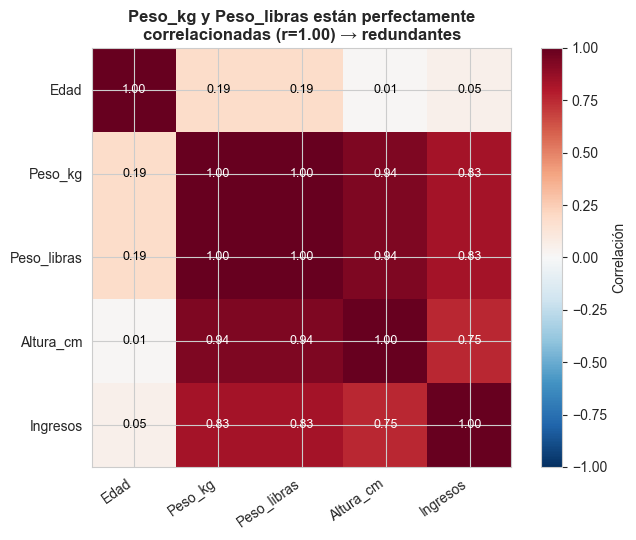

In [36]:
# ── Figura: mapa de calor de correlación (variables redundantes en rojo intenso) ──
fig, ax = plt.subplots(figsize=(7, 5.5))
corr_ejemplo = df_corr.corr()
im = ax.imshow(corr_ejemplo, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_ejemplo.columns)))
ax.set_yticks(range(len(corr_ejemplo.columns)))
ax.set_xticklabels(corr_ejemplo.columns, rotation=35, ha='right')
ax.set_yticklabels(corr_ejemplo.columns)
for i in range(len(corr_ejemplo)):
    for j in range(len(corr_ejemplo)):
        ax.text(j, i, f'{corr_ejemplo.iloc[i,j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_ejemplo.iloc[i,j])>0.6 else 'black', fontsize=9)
plt.colorbar(im, ax=ax, label='Correlación')
ax.set_title('Peso_kg y Peso_libras están perfectamente\ncorrelacionadas (r=1.00) → redundantes', fontweight='bold')
plt.tight_layout()
plt.show()

### SelectKBest

Selecciona las **K variables** que tienen mayor correlación con la variable objetivo,  
usando una función estadística (F-score para regresión, Chi-cuadrado para clasificación).


In [37]:
# Predecir el precio de una casa → ¿cuáles variables importan más?
df_sel = pd.DataFrame({
    'Area_m2':      [60, 80, 95, 120, 75, 100, 55, 85],
    'Habitaciones': [2,  3,  3,  4,   2,  4,   1,  3],
    'Banos':        [1,  1,  2,  2,   1,  2,   1,  2],
    'Antiguedad':   [30, 10, 20, 5,   15, 2,   40, 8],
    'Color_fachada':[3,  1,  2,  1,   3,  2,   1,  3],  # irrelevante para el precio
    'Precio':       [120,160,185,240,140,220,95,175]
})

X = df_sel.drop('Precio', axis=1)
y = df_sel['Precio']

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X, y)

ranking = pd.DataFrame({
    'Variable': X.columns,
    'F_Score':  selector.scores_.round(2),
    'P_valor':  selector.pvalues_.round(4)
}).sort_values('F_Score', ascending=False)

print('Ranking de importancia (SelectKBest con F-score):')
print(ranking)

print('\nSeleccionar las 3 mejores variables:')
selector_k3 = SelectKBest(score_func=f_regression, k=3)
selector_k3.fit(X, y)
mejores = X.columns[selector_k3.get_support()].tolist()
print(f'  → {mejores}')
print('  Color_fachada tiene F_Score muy bajo → es irrelevante para el precio (correcto).')

Ranking de importancia (SelectKBest con F-score):
        Variable  F_Score  P_valor
0        Area_m2   168.47   0.0000
1   Habitaciones   100.39   0.0001
3     Antiguedad    16.89   0.0063
2          Banos    13.76   0.0100
4  Color_fachada     0.22   0.6530

Seleccionar las 3 mejores variables:
  → ['Area_m2', 'Habitaciones', 'Antiguedad']
  Color_fachada tiene F_Score muy bajo → es irrelevante para el precio (correcto).


---
## Reducción de Dimensionalidad


**Definición:** Comprimir muchas variables correlacionadas en un número menor de  
variables **artificiales** que conservan la mayor parte de la información.

**¿Cuándo es necesario?**
- Cuando hay muchas variables correlacionadas (multicolinealidad)
- Para acelerar algoritmos lentos (SVM, redes neuronales)
- Para visualizar datos en 2D o 3D
- Para reducir el sobreajuste en datasets con pocas muestras pero muchas variables


### PCA — Análisis de Componentes Principales

**Cómo funciona:**
1. Encuentra las **direcciones de mayor varianza** en los datos
2. Las ordena de mayor a menor varianza (Componente 1 = mayor varianza)
3. Proyecta los datos sobre estas direcciones

**Resultado:** Nuevas variables (componentes) que son **combinaciones lineales**  
de las originales, ortogonales entre sí (no correlacionadas).

**Requisito:** Estandarizar los datos ANTES de PCA (StandardScaler obligatorio).

**Cuándo usar:**
- Muchas variables correlacionadas
- Antes de SVM, regresión logística con muchas features

**Cuándo NO usar:**
- Si se necesita interpretar las variables (PCA pierde interpretabilidad)
- Árboles de decisión (no se benefician)


In [38]:
# Notas de estudiantes en materias correlacionadas
# (Matemáticas y Física suelen estar correlacionadas; Arte y Educación Física también)
np.random.seed(42)
n = 10
mate  = np.random.randint(60, 100, n)
fisica = mate + np.random.randint(-10, 10, n)  # correlacionada con Mate
arte   = np.random.randint(50, 100, n)
ef     = arte + np.random.randint(-8, 8, n)    # correlacionada con Arte

df_notas = pd.DataFrame({
    'Matemáticas': mate,
    'Física':      np.clip(fisica, 0, 100),
    'Arte':        arte,
    'Ed_Fisica':   np.clip(ef, 0, 100)
})

print('Dataset original (4 variables, algunas correlacionadas):')
print(df_notas)
print(f'\nCorrelaciones:')
print(df_notas.corr().round(2))

Dataset original (4 variables, algunas correlacionadas):
   Matemáticas  Física  Arte  Ed_Fisica
0           98      91    74         70
1           88      85    98         92
2           74      66    76         74
3           67      58    91         87
4           80      81    77         77
5           98      93    65         63
6           78      69    64         57
7           82      72    96         91
8           70      71    93         93
9           70      71    52         55

Correlaciones:
             Matemáticas  Física  Arte  Ed_Fisica
Matemáticas         1.00    0.92 -0.08      -0.16
Física              0.92    1.00 -0.15      -0.17
Arte               -0.08   -0.15  1.00       0.98
Ed_Fisica          -0.16   -0.17  0.98       1.00


In [39]:
# Aplicar PCA
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(df_notas)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

df_pca = pd.DataFrame(X_pca.round(2), columns=['PC1', 'PC2'])
df_pca.index = [f'Est_{i+1}' for i in range(n)]

print('DESPUÉS de PCA (4 variables → 2 componentes):')
print(df_pca)

print(f'\n% de varianza explicada:')
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {v*100:.1f}%')
print(f'  Total: {pca.explained_variance_ratio_.sum()*100:.1f}% de la información original')

print(f'\nComposición de cada componente (peso de cada variable original):')
pd.DataFrame(pca.components_.round(3),
             columns=df_notas.columns,
             index=['PC1','PC2'])

DESPUÉS de PCA (4 variables → 2 componentes):
         PC1   PC2
Est_1  -1.84  1.27
Est_2   0.56  2.00
Est_3   0.55 -0.94
Est_4   2.25 -0.75
Est_5  -0.23  0.21
Est_6  -2.52  0.84
Est_7  -0.84 -1.56
Est_8   1.29  0.97
Est_9   1.84  0.29
Est_10 -1.07 -2.33

% de varianza explicada:
  PC1: 55.9%
  PC2: 41.7%
  Total: 97.6% de la información original

Composición de cada componente (peso de cada variable original):


,Matemáticas,Física,Arte,Ed_Fisica
PC1,-0.464,-0.481,0.516,0.536
PC2,0.536,0.515,0.488,0.457


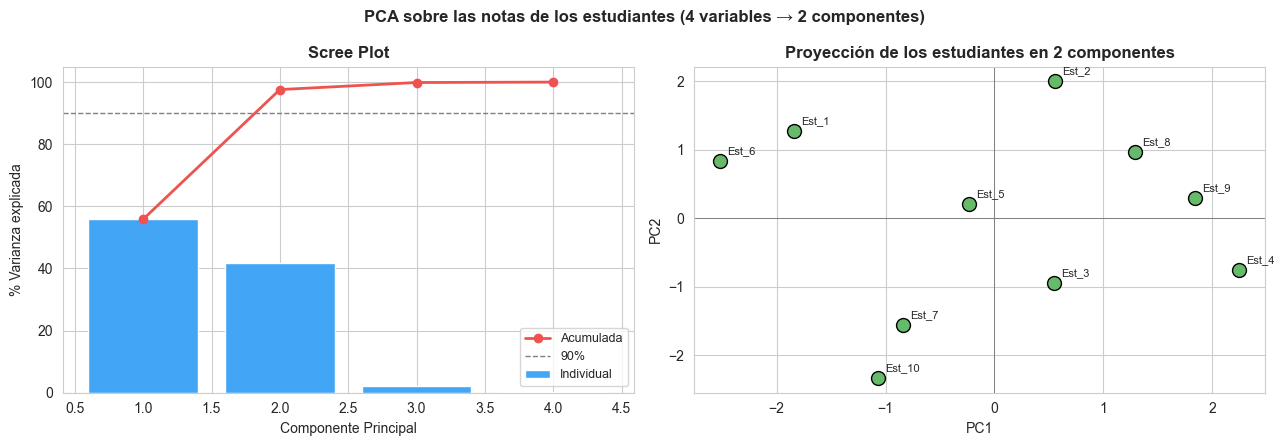

Con solo 2 componente(s) se explica más del 90% de la varianza original.


In [40]:
# ── Figura: Scree Plot — cuánta varianza explica cada componente ──
pca_full = PCA()
pca_full.fit(X_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

var_exp = pca_full.explained_variance_ratio_ * 100
var_acum = np.cumsum(var_exp)

axes[0].bar(range(1, len(var_exp)+1), var_exp, color='#42A5F5', edgecolor='white', label='Individual')
axes[0].plot(range(1, len(var_acum)+1), var_acum, 'o-', color='#EF5350', linewidth=2, label='Acumulada')
axes[0].axhline(90, color='gray', linestyle='--', linewidth=1, label='90%')
axes[0].set_xlabel('Componente Principal')
axes[0].set_ylabel('% Varianza explicada')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].scatter(df_pca['PC1'], df_pca['PC2'], s=100, color='#66BB6A', edgecolor='black')
for idx, row in df_pca.iterrows():
    axes[1].annotate(idx, (row['PC1'], row['PC2']), fontsize=8, xytext=(5,5), textcoords='offset points')
axes[1].axhline(0, color='gray', linewidth=0.7)
axes[1].axvline(0, color='gray', linewidth=0.7)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Proyección de los estudiantes en 2 componentes', fontweight='bold')

plt.suptitle('PCA sobre las notas de los estudiantes (4 variables → 2 componentes)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Con solo {(var_acum < 90).sum()+1} componente(s) se explica más del 90% de la varianza original.')

### t-SNE — t-distributed Stochastic Neighbor Embedding

**Cómo funciona:** Algoritmo no lineal que mapea datos de alta dimensión a 2D/3D,  
preservando la **estructura local** (puntos cercanos en el espacio original  
quedan cercanos en el espacio reducido).

**Cuándo usar:**
- **Exclusivamente para visualización** (no para crear features para modelos)
- Explorar si hay clusters o grupos naturales en datos multidimensionales

**⚠ Limitaciones importantes:**
- Los ejes no tienen interpretación (no son comparables entre ejecuciones)
- No se puede aplicar a datos nuevos (no hay función `transform` estable)
- Lento con datasets grandes
- Las distancias entre clusters no son significativas — solo la separación importa


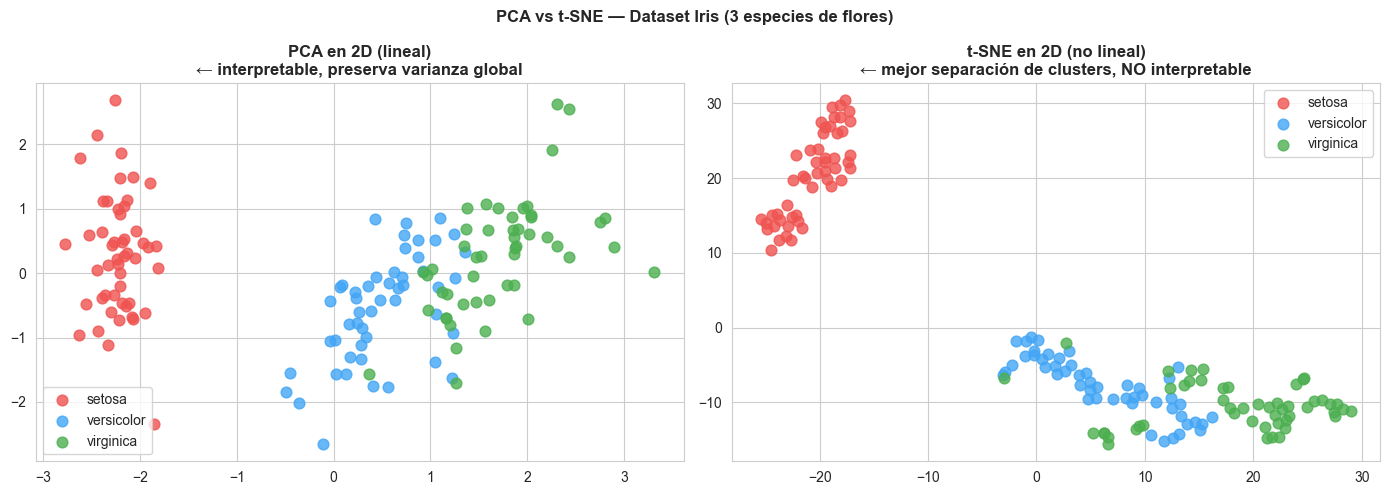

Observación:
  PCA: los grupos están separados pero hay algo de solapamiento (Iris versicolor / virginica).
  t-SNE: los tres clusters están perfectamente separados.
  → t-SNE es útil para confirmar que hay grupos naturales en los datos.
  → PERO no se puede usar para entrenar un modelo (ejes sin significado).


In [41]:
# Usar Iris para demostrar t-SNE (3 clases bien separables)
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

tsne = TSNE(n_components=2, random_state=42, perplexity=15)
X_tsne = tsne.fit_transform(X_iris)

pca2 = PCA(n_components=2)
X_pca_iris = pca2.fit_transform(X_iris)

colores = ['#EF5350','#42A5F5','#4CAF50']
nombres = iris.target_names

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (nombre, color) in enumerate(zip(nombres, colores)):
    mask = y_iris == i
    axes[0].scatter(X_pca_iris[mask,0], X_pca_iris[mask,1], c=color, label=nombre, s=60, alpha=0.8)
    axes[1].scatter(X_tsne[mask,0],     X_tsne[mask,1],     c=color, label=nombre, s=60, alpha=0.8)

axes[0].set_title('PCA en 2D (lineal)\n← interpretable, preserva varianza global', fontweight='bold')
axes[1].set_title('t-SNE en 2D (no lineal)\n← mejor separación de clusters, NO interpretable', fontweight='bold')
for ax in axes:
    ax.legend()

plt.suptitle('PCA vs t-SNE — Dataset Iris (3 especies de flores)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación:')
print('  PCA: los grupos están separados pero hay algo de solapamiento (Iris versicolor / virginica).')
print('  t-SNE: los tres clusters están perfectamente separados.')
print('  → t-SNE es útil para confirmar que hay grupos naturales en los datos.')
print('  → PERO no se puede usar para entrenar un modelo (ejes sin significado).')

---
# Resumen General — Las 5 Categorías

| Categoría | Técnicas | Se usa cuando... |
|---|---|---|
| **1. Escalado** | MinMax, MaxAbs, Standard, Robust | Las variables numéricas tienen escalas muy distintas |
| **2. Forma de la distribución** | log, sqrt, Box-Cox, Yeo-Johnson, Winsorizing, Quantile | Hay asimetría fuerte u outliers que distorsionan el modelo |
| **3. Creación de variables** | Discretización, Binarización, Polynomial, Feature Eng., Fecha/Hora | Las variables originales no capturan bien la relación con el objetivo |
| **4. Codificación categórica** | Label, One-Hot, Ordinal, Target, Frequency, Binary | Hay variables de texto que el algoritmo necesita como números |
| **5. Selección / Reducción** | Variance Threshold, Correlación, SelectKBest, PCA, t-SNE | Hay demasiadas variables, redundantes o poco informativas |


## Guía de selección rápida por tipo de variable y algoritmo

### Según el tipo de variable

### Variable numérica continua:
| Si la distribución es... | Técnica |
|---|---|
| Simétrica, sin outliers | MinMaxScaler o StandardScaler |
| Con outliers | RobustScaler o Winsorizing + StandardScaler |
| Muy asimétrica (positiva) | log1p → luego escalar |
| Asimetría desconocida | Yeo-Johnson |
| Distribución irregular | QuantileTransformer |

### Variable numérica → categorías:
| Objetivo | Técnica |
|---|---|
| Crear rangos de igual ancho | pd.cut() (Equal Width) |
| Crear grupos balanceados | pd.qcut() (Equal Frequency) |
| Crear indicador 0/1 | Binarización con umbral |

### Variable categórica → números:
| Tipo | Técnica |
|---|---|
| Nominal, pocas categorías (<15) | One-Hot Encoding |
| Ordinal (tiene orden natural) | Ordinal Encoding |
| Nominal, muchas categorías | Target o Frequency Encoding |
| Alta cardinalidad, menos columnas | Binary Encoding |
| Árboles de decisión (cualquier caso) | Label Encoding |

### Según el algoritmo que se va a usar

| Algoritmo | Necesita escalado | Encoding recomendado | Otras transformaciones |
|---|---|---|---|
| Árbol de decisión / Random Forest | ❌ No | Label Encoding | Ninguna necesaria |
| XGBoost / LightGBM | ❌ No | Label Encoding o Target | Ninguna necesaria |
| Regresión lineal / logística | ✅ StandardScaler | One-Hot | log o Box-Cox si hay asimetría |
| SVM | ✅ StandardScaler | One-Hot | log si hay asimetría |
| KNN / K-Means | ✅ MinMaxScaler | One-Hot | Ninguna especial |
| Red Neuronal | ✅ MinMaxScaler o Standard | One-Hot o Embeddings | log para variables muy sesgadas |
| PCA | ✅ StandardScaler (obligatorio) | One-Hot | Aplicar ANTES de PCA |
